# Simulation of Quantum Key Distribution over a Free-Space Optical Channel
## A beginner's step-by-step guide, with LDPC reconciliation and privacy amplification

**The question we are exploring:** how can Alice and Bob create matching key bits when an optical link loses photons, introduces errors, and may be disturbed by an eavesdropper?

Alice is the sender. Bob is the receiver. Eve represents an eavesdropper. **QKD** means quantum key distribution: establishing shared key material. **FSO** means free-space optical: light travels through open air. **LDPC** means low-density parity-check: a sparse collection of parity rules helps Bob correct his bits. These are three different jobs within the project.

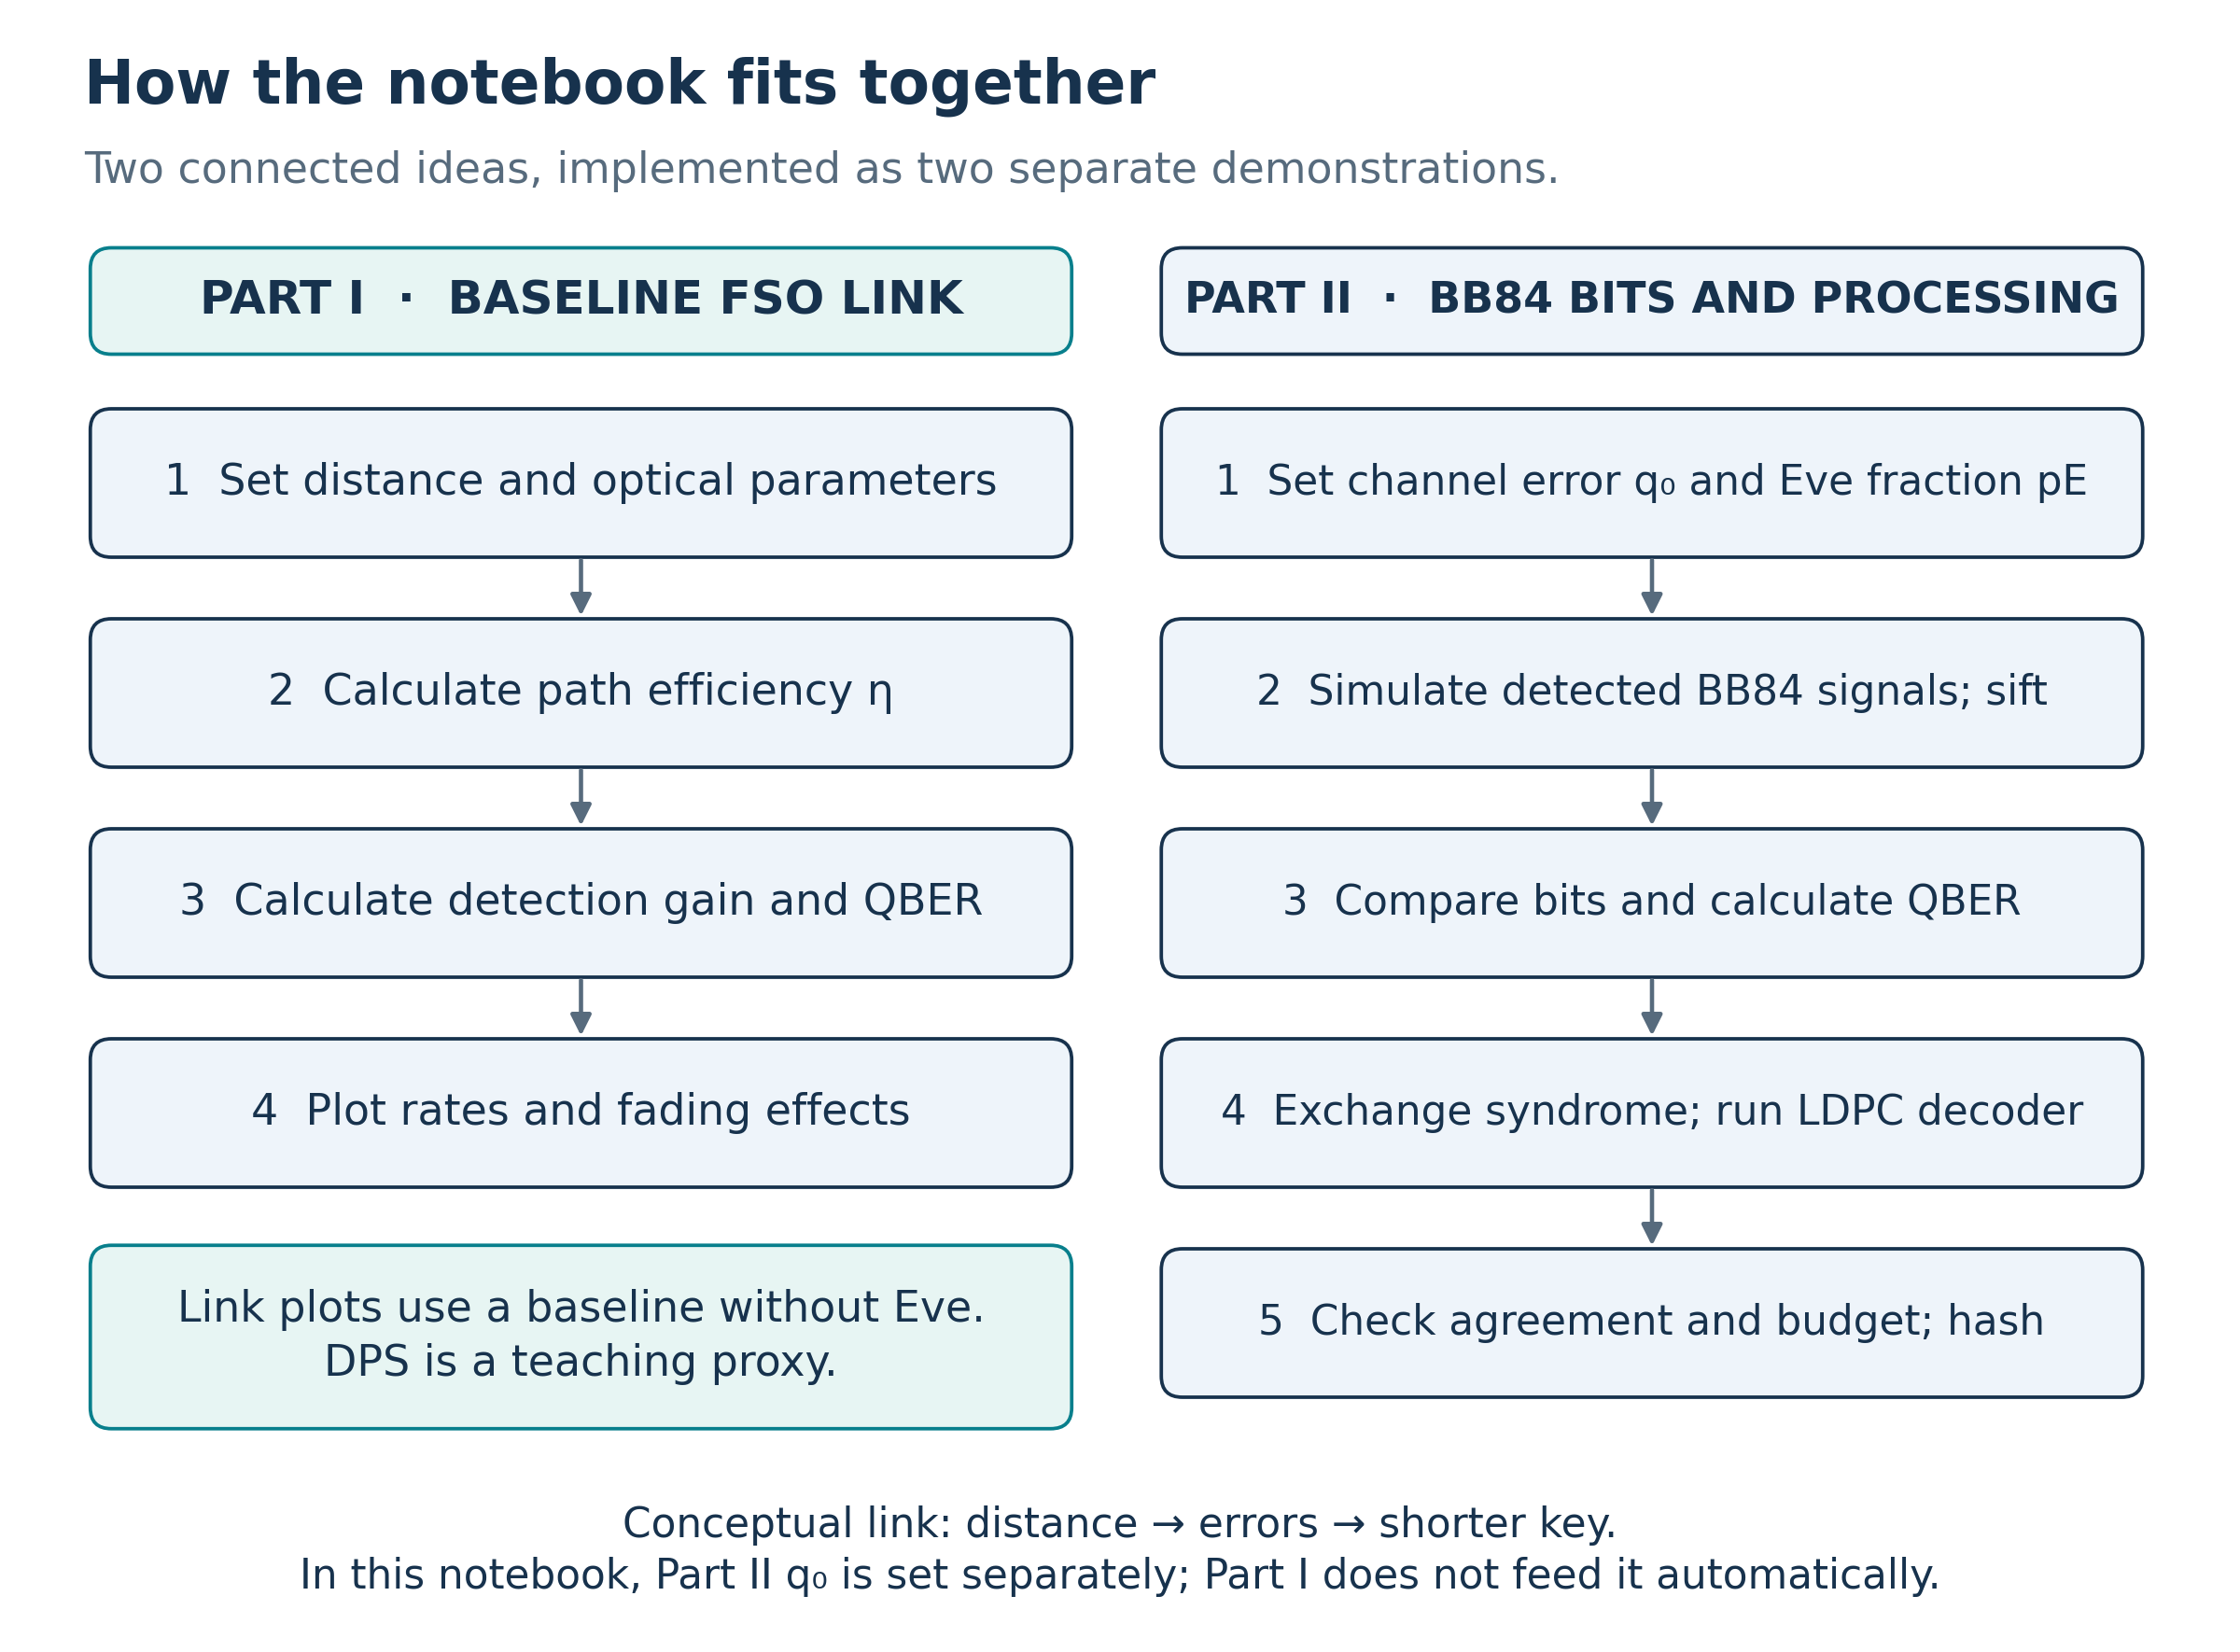

### Follow these steps through the notebook

1. **Study the optical path.** Calculate how much light Bob can collect as distance increases.
2. **Estimate detections and errors.** Calculate the probability of a detector click and the fraction of detected bits that are wrong.
3. **Read the rate graphs.** See how loss and errors reduce modelled key rates.
4. **Create sample BB84 bits.** Simulate Alice, Bob, and Eve, then keep positions with matching Alice/Bob measurement bases.
5. **Correct Bob's errors.** Exchange parity information and decode the likely error positions.
6. **Shorten the corrected key.** Use a Toeplitz hash to illustrate privacy amplification.
7. **Inspect the outcome.** Check whether correction succeeded and whether the illustrative budget permits a final key.

### An important connection to keep clear

**Part I and Part II are separate numerical experiments.** Part I calculates a distance-dependent FSO baseline with no Eve. Part II begins with already-detected, ideal single-photon BB84 signals and uses the independently configured `demo_channel_qber`. The code does not automatically feed the 20 km FSO QBER into the bit simulation. The overview diagram shows this separation because otherwise two different QBER values can look contradictory.

Read each explanation, inspect its diagram or example, and then run the code immediately below it. You can understand the process before understanding every Python line. A formula's symbols are explained where they first appear.

**Scope:** this is an educational simulation. Its FSO assumptions, DPS proxy, small LDPC construction, and final-key budget have specific limitations explained below. It does not establish production security. Course PDFs cited in the original project are absent from this workspace, so correspondence with those lectures has not been verified here.

## 1. Prepare Python and make the results repeatable

**Purpose:** load the tools used throughout the notebook and choose a repeatable starting point for random experiments.

1. `math` provides basic mathematical operations used by the decoder.
2. `numpy`, shortened to `np`, stores bit arrays, performs calculations, and draws random samples.
3. `matplotlib.pyplot`, shortened to `plt`, draws the plots.
4. `SEED = 11` fixes a random starting state. Some later experiments use their own explicitly specified seeds.

**Expected output:** `Ready. Random seed = 11`. If imports fail, the Python environment running this notebook needs NumPy and Matplotlib installed. The notebook interface itself also needs Jupyter or another compatible notebook application.

### How to run without mixing old and new values

1. Open this `.ipynb` file in your notebook application.
2. Start with the supplied defaults and use **Restart Kernel and Run All**, or the equivalent command.
3. Read the outputs from top to bottom.
4. To experiment, edit a parameter, then restart and run all cells again.
5. Compare that run with your saved baseline.

Restarting matters because Python evaluates function default arguments when the function is defined. Several functions capture values from `P` in their defaults. Editing `P` and running only a later plot can therefore mix updated settings with old defaults. A complete run also resets the random generators and recreates the dependent key arrays.

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

SEED = 11
rng = np.random.default_rng(SEED)
np.set_printoptions(precision=4, suppress=True)
print("Ready. Random seed =", SEED)

Ready. Random seed = 11


## 2. Understand the settings before changing them

`P` is a Python dictionary: each quoted name identifies one assumption. These defaults describe an illustrative terrestrial line-of-sight link, rather than a measured commercial system.

| Parameter | Default | Simple meaning |
|---|---:|---|
| `w0_m` | 0.05 m | Initial beam radius: 5 cm. |
| `divergence_rad` | 0.000050 rad | How quickly the beam spreads. |
| `receiver_radius_m` | 0.10 m | Bob's collecting aperture radius: 10 cm. |
| `atmospheric_loss_db_km` | 0.20 dB/km | Attenuation accumulated per kilometre. |
| `optical_efficiency` | 0.70 | Fraction surviving the receiving optics. |
| `detector_efficiency` | 0.25 | Detection efficiency after the optics. |
| `mu_signal` | 0.50 | Average photons per weak coherent signal pulse. |
| `dark_yield` | 0.000002 | Background/dark click probability per detector gate. |
| `bb84_misalignment` | 0.015 | Part I BB84 signal error probability: 1.5%. |
| `dps_visibility` | 0.98 | Interference quality used in the DPS optical-error model. |
| `ec_efficiency` | 1.16 | Assumed error-correction cost factor in Part I rates. |
| `eve_intercept_fraction` | 0.08 | Part II probability Eve intercepts a signal: 8%. |
| `demo_channel_qber` | 0.02 | Part II independent channel flip probability: 2%. |
| `turbulence_strength` | 0.25 | Strength knob for the illustrative fading distribution. |

**Step 1:** distinguish units. A radius of `0.10` means metres, while `0.02` for an error probability means 2%. `50e-6` means $50\times10^{-6}$, or 0.000050.

**Step 2:** keep probability and count separate. `mu_signal = 0.50` does not mean that every pulse contains half a photon. It is an average over pulses with different photon numbers.

**Step 3:** change one setting per comparison. Increasing the receiver radius should improve collection; increasing atmospheric loss should reduce it. Changing `demo_channel_qber` changes the Part II bit experiment, not the Part I FSO curves.

**Step 4:** restart and run all. The two atmospheric-loss curves later explicitly use 0.20 and 0.60 dB/km, so changing only `P` does not change those particular curve labels or overrides.

In [2]:
P = {
    # Optical / FSO assumptions
    "w0_m": 0.05,                 # initial beam radius (m)
    "divergence_rad": 50e-6,     # beam divergence (rad)
    "receiver_radius_m": 0.10,   # receiver aperture radius (m)
    "atmospheric_loss_db_km": 0.20,  # clear-air attenuation
    "optical_efficiency": 0.70,
    "detector_efficiency": 0.25,

    # QKD / detector assumptions
    "mu_signal": 0.50,           # mean photons/pulse for WCP signal state
    "dark_yield": 2e-6,          # background/dark click probability per gate
    "bb84_misalignment": 0.015,  # optical/misalignment error probability
    "dps_visibility": 0.98,      # interferometer visibility
    "ec_efficiency": 1.16,       # f >= 1; 1 is Shannon ideal

    # BB84 intercept-resend teaching demo (conditioned on detected signals)
    "eve_intercept_fraction": 0.08,  # 0 = no Eve; 1 = intercept every signal
    "demo_channel_qber": 0.02,       # independent channel errors, before Eve

    # Turbulence teaching model
    "turbulence_strength": 0.25, # dimensionless log-normal fading knob
}

P

{'w0_m': 0.05,
 'divergence_rad': 5e-05,
 'receiver_radius_m': 0.1,
 'atmospheric_loss_db_km': 0.2,
 'optical_efficiency': 0.7,
 'detector_efficiency': 0.25,
 'mu_signal': 0.5,
 'dark_yield': 2e-06,
 'bb84_misalignment': 0.015,
 'dps_visibility': 0.98,
 'ec_efficiency': 1.16,
 'eve_intercept_fraction': 0.08,
 'demo_channel_qber': 0.02,
 'turbulence_strength': 0.25}

## 3. Binary entropy: the cost of uncertainty

**Purpose:** turn an error probability into a measure of uncertainty per bit. The function is

$$h_2(x)=-x\log_2(x)-(1-x)\log_2(1-x).$$

Here, $x$ is a probability between zero and one. The subscript 2 means that logarithms use base 2, so the result is measured in bits.

1. If $x=0$, there is no uncertainty about whether an error occurs; mathematically $h_2(0)=0$.
2. If $x=0.5$, an error and no error are equally likely; $h_2(0.5)=1$.
3. If $x=0.04$, the next cell prints approximately **0.2423**.

**Worked meaning:** for 1,000 independent bits passing through an ideal binary symmetric channel with 4% errors, $1000h_2(0.04)\approx242.3$ bits is the asymptotic information benchmark used here for reconciliation. The expected number of wrong bits is only 40. Those are different quantities: identifying the unknown error positions costs information too.

The code clips inputs away from exactly zero and one so it never asks Python to calculate `log2(0)`. Tiny numerical endpoint differences do not change the intended interpretation. Later sections use this same helper both for rate penalties and for the illustrative privacy budget.

In [3]:
def h2(x):
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 1e-15, 1 - 1e-15)
    return -x*np.log2(x) - (1-x)*np.log2(1-x)

print("h2(0.04) =", float(h2(0.04)))

h2(0.04) = 0.24229218908241482


## 4. Build the FSO link one loss at a time

**Purpose:** calculate the total detection-path efficiency $\eta$, a fraction between zero and one. It combines collection, atmospheric transmission, receiving optics, and detector efficiency.

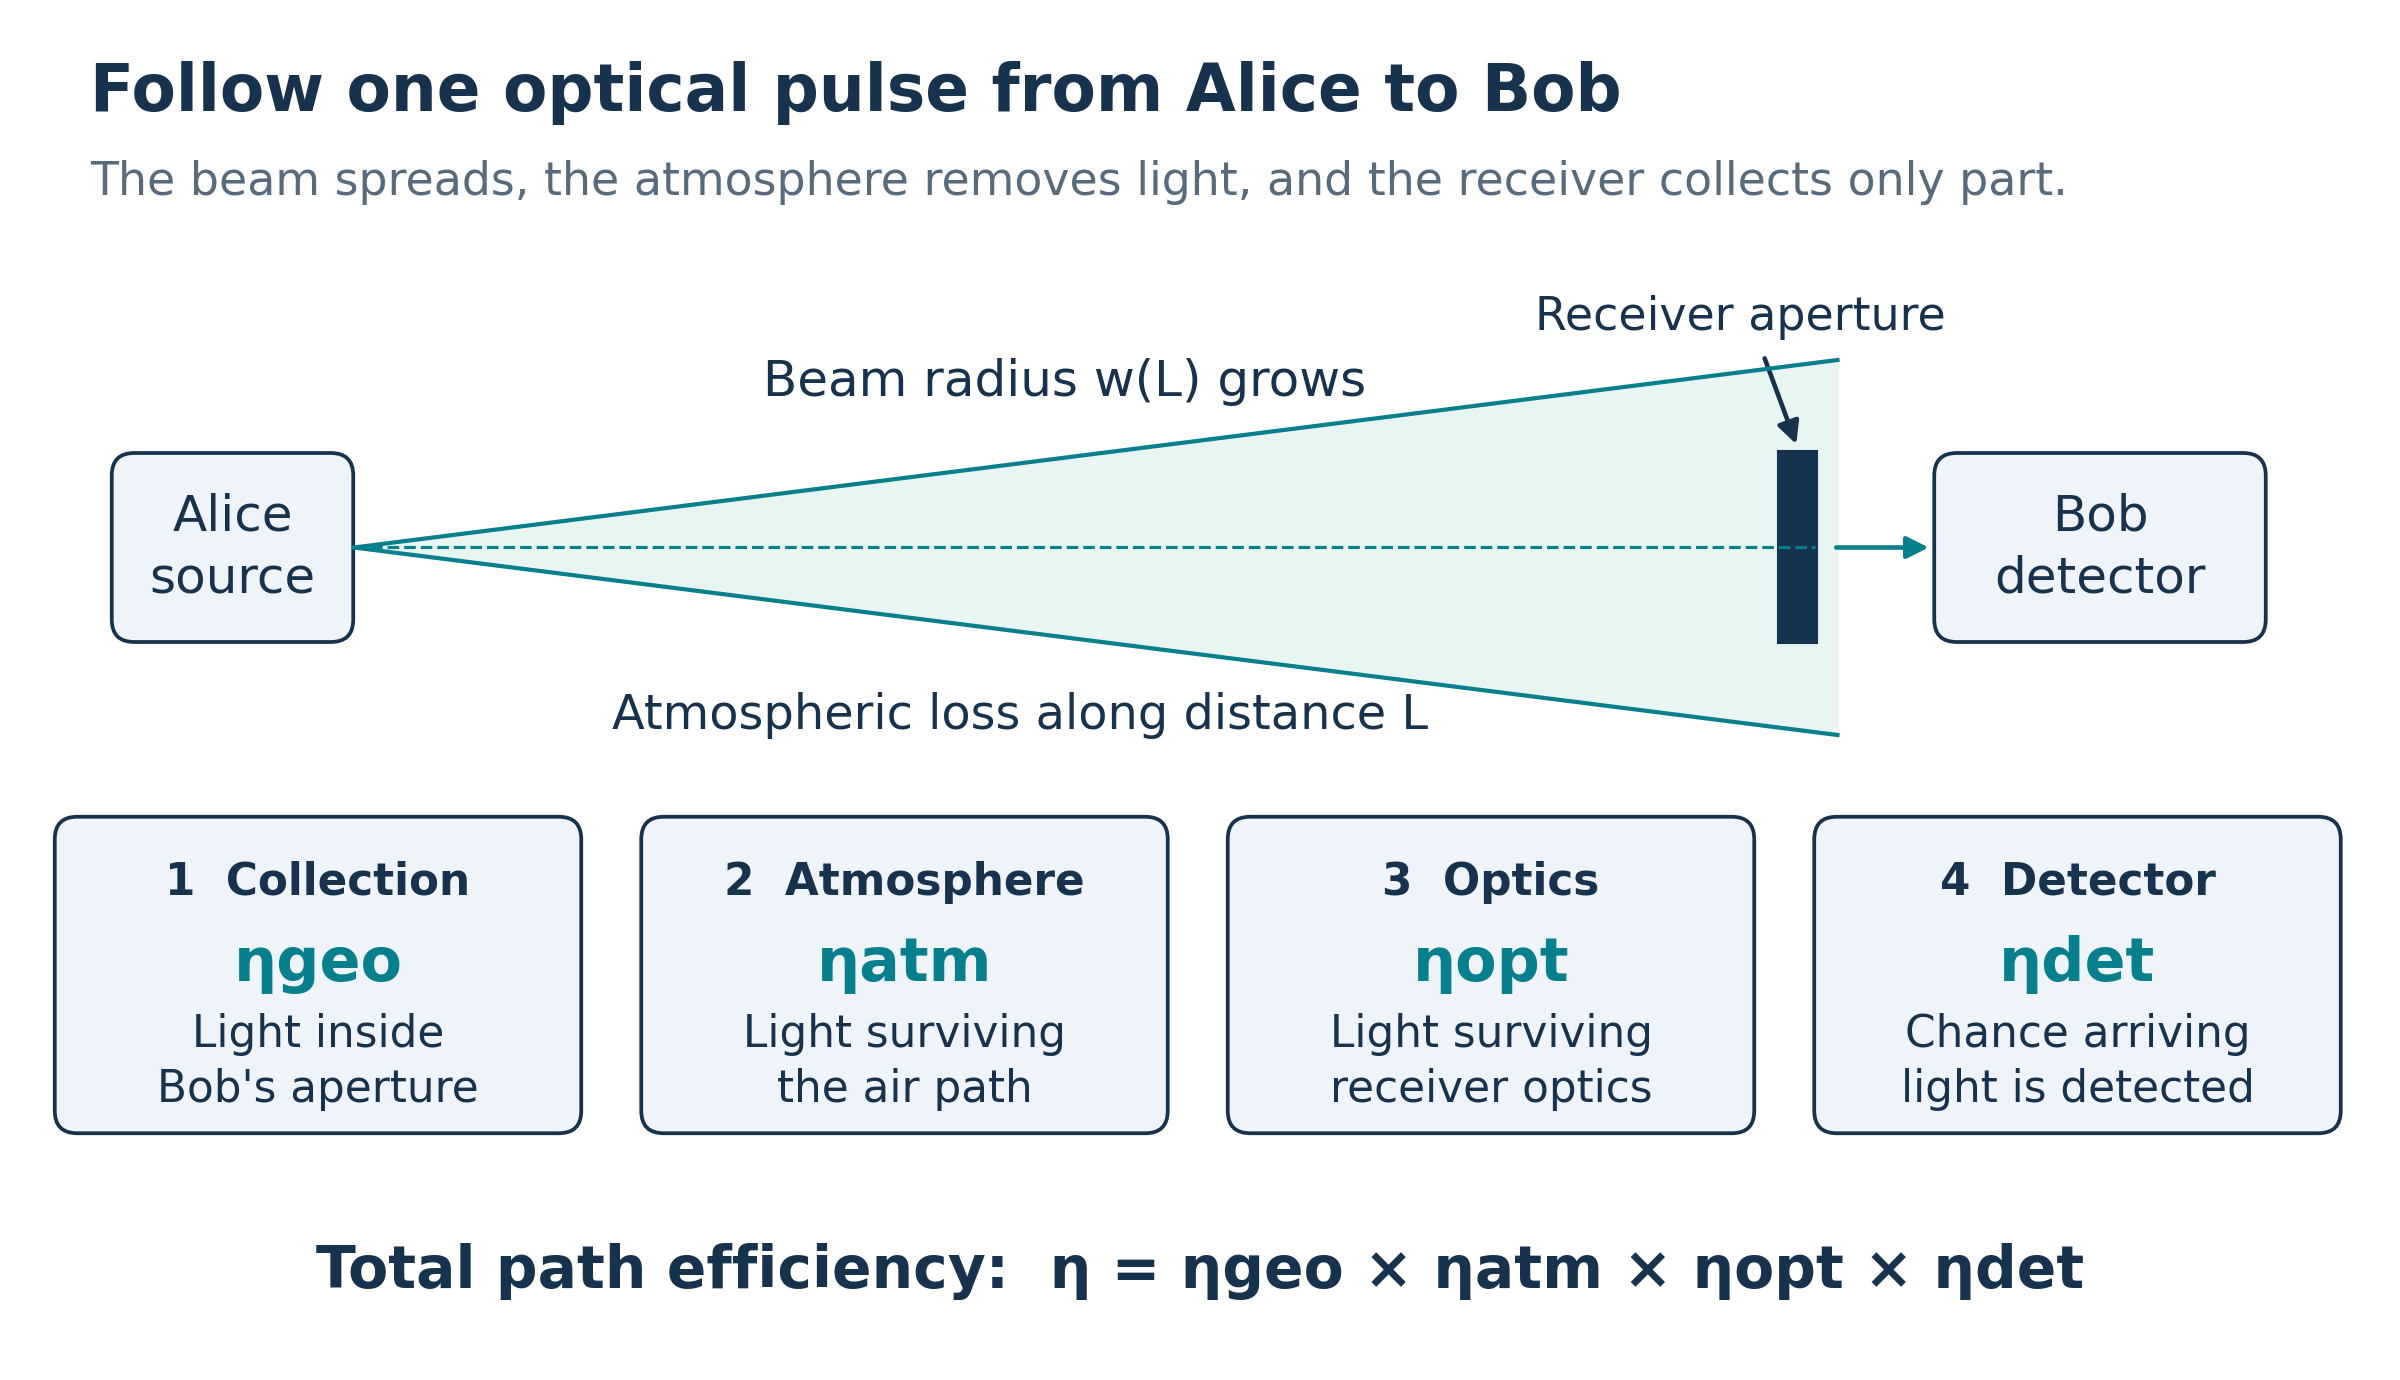

### Step 1 — Calculate the beam radius at Bob

$$w(L)=\sqrt{w_0^2+(\theta L)^2}.$$

$w_0$ is the initial radius, $\theta$ the divergence angle, and $L$ the distance **in metres** in this equation. The function accepts kilometres and multiplies by 1,000 internally. A wider beam spreads the available light across a larger area.

### Step 2 — Calculate the fraction Bob collects

$$\eta_{geo}=1-\exp\left(-\frac{2r_r^2}{w(L)^2}\right).$$

$r_r$ is the receiver radius. This formula assumes the stated Gaussian beam and centred circular aperture. When the beam becomes much wider than the receiver, more light misses the aperture.

### Step 3 — Calculate atmospheric transmission

$$\eta_{atm}=10^{-\alpha L_{km}/10}.$$

$\alpha$ is attenuation in dB/km and $L_{km}$ is distance in kilometres. At 20 km with 0.20 dB/km, the accumulated attenuation is 4 dB, giving transmission $10^{-0.4}\approx0.3981$.

### Step 4 — Multiply the surviving fractions

$$\eta=\eta_{geo}\eta_{atm}\eta_{opt}\eta_{det}.$$

At 20 km, the default beam radius is about 1.001 m and geometric collection is about 0.01975. Therefore

$$\eta\approx0.01975\times0.3981\times0.70\times0.25\approx0.001376.$$

That is **0.1376% total detection-path efficiency**. It is not yet the pulse click probability: the pulse's mean photon number enters in Section 5.

**Read the output:** the quick check should show efficiency decreasing from about 0.164 at 1 km to 0.001376 at 20 km. `1.376e-03` means 0.001376.

These are engineering assumptions. The notebook does not simulate detailed pointing jitter, aerosols, aperture averaging, or a complete atmospheric turbulence model. Its later fading factor adds a simple random variation to this baseline.

In [4]:
def beam_radius(distance_km, w0_m=P["w0_m"], divergence_rad=P["divergence_rad"]):
    L_m = np.asarray(distance_km, dtype=float) * 1000.0
    return np.sqrt(w0_m**2 + (divergence_rad * L_m)**2)


def geometric_coupling(distance_km, receiver_radius_m=P["receiver_radius_m"]):
    w = beam_radius(distance_km)
    return 1.0 - np.exp(-2.0 * receiver_radius_m**2 / (w**2))


def atmospheric_transmittance(distance_km, alpha_db_km=P["atmospheric_loss_db_km"]):
    return 10.0 ** (-alpha_db_km * np.asarray(distance_km, dtype=float) / 10.0)


def deterministic_eta(distance_km, alpha_db_km=P["atmospheric_loss_db_km"]):
    return (geometric_coupling(distance_km)
            * atmospheric_transmittance(distance_km, alpha_db_km)
            * P["optical_efficiency"]
            * P["detector_efficiency"])


def lognormal_fading(distance_km, size=1, strength=P["turbulence_strength"], rng=None):
    """Simple normalized log-normal intensity factor with mean approximately 1."""
    if rng is None:
        rng = np.random.default_rng()
    sigma = strength * np.sqrt(np.asarray(distance_km, dtype=float) / 10.0)
    # Scalar-distance use is enough for this notebook's Monte Carlo section.
    sigma = float(np.asarray(sigma))
    return np.exp(rng.normal(loc=-0.5*sigma**2, scale=sigma, size=size))

# Quick check
for d in [1, 5, 10, 20]:
    print(f"{d:>2} km: eta = {deterministic_eta(d):.4e}")

 1 km: eta = 1.6406e-01
 5 km: eta = 3.6817e-02
10 km: eta = 8.4085e-03
20 km: eta = 1.3761e-03


### 4.1 Read the efficiency-versus-distance graph

1. **Find the horizontal axis:** distance in kilometres, from 0.5 to 80.
2. **Find the vertical axis:** total detection-path efficiency, including detector efficiency.
3. **Read the legend:** 0.20 dB/km is the lower-attenuation case; 0.60 dB/km is the higher-attenuation comparison.
4. **Compare at the same distance:** the lower curve means fewer useful detection opportunities.

The vertical axis is logarithmic. Moving from $10^{-2}$ to $10^{-3}$ is a factor-of-ten reduction, not a subtraction of one percentage point. This scale makes very small long-distance efficiencies visible.

Both curves decrease because the beam expands and atmospheric loss accumulates. The higher-attenuation curve decreases faster. Their difference shows the effect of changing atmospheric attenuation while keeping the aperture, beam, optics, and detector assumptions fixed.

**Check your understanding:** at a chosen distance, explain separately why a larger receiver could improve collection and why it cannot recover photons already lost in the atmosphere. The plot studies deterministic link loss; it does not include Eve or random fading.

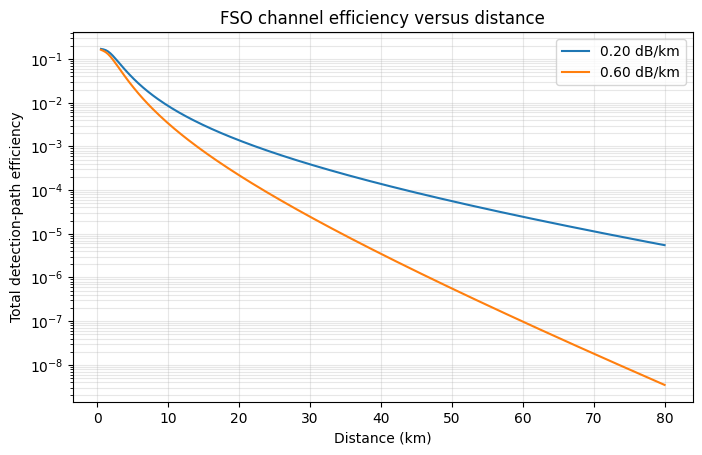

In [5]:
distances = np.linspace(0.5, 80, 240)
eta_clear = deterministic_eta(distances, alpha_db_km=0.20)
eta_hazy  = deterministic_eta(distances, alpha_db_km=0.60)

plt.figure(figsize=(8, 4.8))
plt.semilogy(distances, eta_clear, label="0.20 dB/km")
plt.semilogy(distances, eta_hazy, label="0.60 dB/km")
plt.xlabel("Distance (km)")
plt.ylabel("Total detection-path efficiency")
plt.title("FSO channel efficiency versus distance")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

## 5. From optical efficiency to detector clicks and QBER

**QBER**, or quantum bit error rate, is the fraction of compared key bits that disagree. A value of 0.02 is a 2% error rate. A detector click probability and an error fraction answer different questions.

### Step 1 — Estimate signal clicks per pulse

$$S=1-e^{-\mu\eta}.$$

$\mu$ is the average photons per pulse and $\eta$ is the path efficiency. `signal_click` stores $S$. For small $\mu\eta$, the approximation $S\approx\mu\eta$ helps you check the number.

### Step 2 — Add background clicks

$$Q_\mu\approx S+Y_0.$$

$Y_0$ is the dark/background yield. $Q_\mu$, called the detection gain, is a probability per transmitted pulse. This additive expression is the notebook's small-probability approximation.

### Step 3 — Count the wrong-click contribution

$$E_\mu=\frac{e_dS+\tfrac12Y_0}{Q_\mu}.$$

$e_dS$ represents erroneous signal detections. Random background clicks are wrong half the time, giving $Y_0/2$. Dividing by total clicks produces their error fraction.

At 20 km, the defaults give $S\approx0.0006878$, $Q_\mu\approx0.0006898$, and BB84 QBER about **1.641%**. As the useful signal fades, background makes up a larger share of detections, and the model's QBER rises toward 50%.

### Step 4 — Read the two protocol curves

BB84 uses `bb84_misalignment`, or 1.5%. The DPS optical-error model uses

$$e_{DPS}=(1-V)/2,$$

where $V$ is visibility. With $V=0.98$, this error is 1%. Their different starting errors help explain the separation between the curves.

The dashed line near 11% is a familiar ideal simple-BB84 reference. It is not a universal cutoff: the later `f = 1.16` correction cost, the decoy expression, and the Part II budget can reach zero under different conditions.

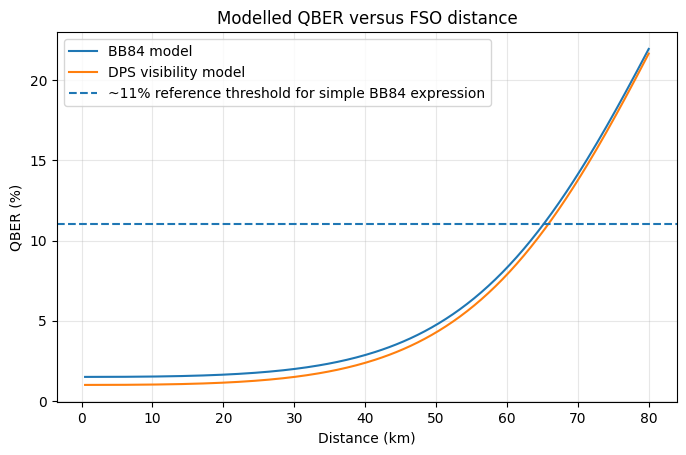

In [6]:
def gain_and_qber(distance_km, protocol="BB84", alpha_db_km=P["atmospheric_loss_db_km"]):
    eta = deterministic_eta(distance_km, alpha_db_km=alpha_db_km)
    mu = P["mu_signal"]
    y0 = P["dark_yield"]
    signal_click = 1.0 - np.exp(-mu * eta)
    Q = signal_click + y0

    if protocol.upper() == "DPS":
        ed = (1.0 - P["dps_visibility"]) / 2.0
    else:
        ed = P["bb84_misalignment"]

    E = (ed * signal_click + 0.5*y0) / np.maximum(Q, 1e-30)
    return Q, E, eta

Q_b, E_b, _ = gain_and_qber(distances, "BB84")
Q_d, E_d, _ = gain_and_qber(distances, "DPS")

plt.figure(figsize=(8, 4.8))
plt.plot(distances, 100*E_b, label="BB84 model")
plt.plot(distances, 100*E_d, label="DPS visibility model")
plt.axhline(11, linestyle="--", label="~11% reference threshold for simple BB84 expression")
plt.xlabel("Distance (km)")
plt.ylabel("QBER (%)")
plt.title("Modelled QBER versus FSO distance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Calculate three different rate estimates

**Purpose:** estimate usable bits per transmitted pulse under the stated formulas. A larger detector click probability is helpful, but error correction and privacy costs reduce the useful output.

### 6.1 Simplified BB84 reference: work through the factors

$$R_{ref}=Q_\mu q\max\{1-fh_2(E_\mu)-h_2(E_\mu),0\}.$$

1. Start with $Q_\mu$: how often a pulse produces a click.
2. Multiply by $q=0.5$: with independent, equally likely BB84 bases, roughly half the detections survive sifting.
3. Subtract the reconciliation cost $fh_2(E_\mu)$, using the assumed $f=1.16$.
4. Subtract the additional entropy term $h_2(E_\mu)$ in this reference expression.
5. Replace negative results with zero. A negative mathematical budget does not represent a negative physical key.

This is a simplified reference, not a complete treatment of weak coherent pulses or arbitrary attacks.

### 6.2 Decoy-BB84: identify the single-photon contribution

$$R_{decoy}=q\left[Q_1(1-h_2(e_1))-Q_\mu f h_2(E_\mu)\right],$$

followed by clipping at zero. The symbols mean:

| Symbol | Meaning in this notebook |
|---|---|
| $Y_1$ | Estimated click probability given a single-photon pulse. |
| $e_1$ | Estimated error fraction of that single-photon contribution. |
| $Q_1$ | Probability per emitted signal pulse of a single-photon contribution and detection. |
| $Q_\mu,E_\mu$ | Overall signal-state detection gain and QBER. |

The code sets $Y_1=1-(1-Y_0)(1-\eta)$, estimates $e_1$, and uses $Q_1=\mu e^{-\mu}Y_1$. The factor $\mu e^{-\mu}$ is the single-photon probability for the assumed coherent-pulse photon-number distribution.

The positive term credits the estimated single-photon contribution; the negative term charges reconciliation on the overall signal detections. This notebook estimates these quantities directly from its channel assumptions. It does not simulate several decoy intensities and infer statistical bounds from measured data. Existing code labels referring to a lecture formula are inherited project labels; the source lectures were unavailable for this revision.

### 6.3 DPS: read this curve as a teaching proxy

The DPS proxy reuses the reference entropy penalty with $q=1$ and the visibility-based optical error. That makes a useful comparison of throughput assumptions, but it is **not a proven DPS secure-key bound**. Avoiding BB84 basis sifting does not remove the need for error reconciliation and privacy amplification in a DPS protocol.

**Reading the graph:** compare rates at one distance and remember the logarithmic vertical scale. A value of $10^{-4}$ means 0.0001 bits per pulse. At an illustrative one million pulses per second, multiplication gives 100 bits/s under the formula, before omitted practical overheads. Zero computed rates are displayed at $10^{-12}$ solely so they can appear on the logarithmic plot; the numerical table is the clearer place to check actual zeros.

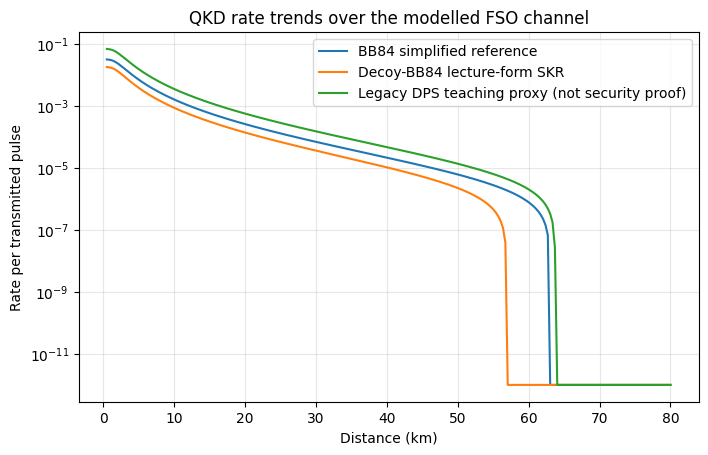

In [7]:
def bb84_reference_rate(distance_km):
    Q, E, _ = gain_and_qber(distance_km, "BB84")
    q = 0.5
    f = P["ec_efficiency"]
    secret_fraction = 1.0 - f*h2(E) - h2(E)
    return Q * q * np.maximum(secret_fraction, 0.0)


def decoy_bb84_rate(distance_km):
    Qmu, Emu, eta = gain_and_qber(distance_km, "BB84")
    mu = P["mu_signal"]
    y0 = P["dark_yield"]
    ed = P["bb84_misalignment"]
    f = P["ec_efficiency"]
    q = 0.5

    # Simple single-photon yield/error approximation for the project simulation.
    Y1 = 1.0 - (1.0-y0)*(1.0-eta)
    e1 = (ed*eta + 0.5*y0) / np.maximum(Y1, 1e-30)
    Q1 = mu * np.exp(-mu) * Y1

    R = q * (Q1*(1.0-h2(e1)) - Qmu*f*h2(Emu))
    return np.maximum(R, 0.0)


def dps_teaching_proxy(distance_km):
    Q, E, _ = gain_and_qber(distance_km, "DPS")
    f = P["ec_efficiency"]
    q = 1.0  # no basis reconciliation in the lecture description
    fraction = 1.0 - f*h2(E) - h2(E)
    return Q * q * np.maximum(fraction, 0.0)

R_bb84 = bb84_reference_rate(distances)
R_decoy = decoy_bb84_rate(distances)
R_dps = dps_teaching_proxy(distances)

plt.figure(figsize=(8, 4.8))
plt.semilogy(distances, np.maximum(R_bb84, 1e-12), label="BB84 simplified reference")
plt.semilogy(distances, np.maximum(R_decoy, 1e-12), label="Decoy-BB84 lecture-form SKR")
plt.semilogy(distances, np.maximum(R_dps, 1e-12), label="Legacy DPS teaching proxy (not security proof)")
plt.xlabel("Distance (km)")
plt.ylabel("Rate per transmitted pulse")
plt.title("QKD rate trends over the modelled FSO channel")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()

### 6.4 Use the numerical table to check the graphs

The next cell prints the same model quantities at selected distances. Each row is one distance, and each rate column is measured **per transmitted pulse**.

1. Read `eta` as the total detection-path efficiency.
2. Read `QBER%` as the BB84 error percentage, not the DPS error percentage.
3. Compare `BB84 rate`, `Decoy rate`, and `DPS proxy` while preserving their different meanings.
4. Look for a printed zero when an expression no longer allows a positive rate.

For the supplied defaults, the 20 km row should be approximately:

| Quantity | Value |
|---|---:|
| Total efficiency | 0.001376 |
| BB84 QBER | 1.641% |
| Simplified BB84 rate | 0.0002549 bits/pulse |
| Decoy-BB84 model rate | 0.0001363 bits/pulse |
| Legacy DPS teaching proxy | 0.0005556 bits/pulse |

At 60 km, the default decoy expression prints zero even though the simple reference remains slightly positive. This illustrates why a single QBER threshold cannot replace examining the actual rate formula and assumptions. Save this table as your baseline before changing settings.

In [8]:
selected = [1, 5, 10, 20, 30, 40, 60]
print(f"{'km':>4} {'eta':>11} {'QBER%':>9} {'BB84 rate':>13} {'Decoy rate':>13} {'DPS proxy':>13}")
for d in selected:
    Q, E, eta = gain_and_qber(d, "BB84")
    print(f"{d:4.0f} {eta:11.3e} {100*E:9.3f} {bb84_reference_rate(d):13.3e} {decoy_bb84_rate(d):13.3e} {dps_teaching_proxy(d):13.3e}")

  km         eta     QBER%     BB84 rate    Decoy rate     DPS proxy
   1   1.641e-01     1.501     2.982e-02     1.695e-02     6.500e-02
   5   3.682e-02     1.505     6.901e-03     3.763e-03     1.504e-02
  10   8.409e-03     1.523     1.583e-03     8.542e-04     3.451e-03
  20   1.376e-03     1.641     2.549e-04     1.363e-04     5.556e-04
  30   3.886e-04     1.994     6.822e-05     3.563e-05     1.487e-04
  40   1.382e-04     2.864     2.116e-05     1.030e-05     4.621e-05
  60   2.450e-05     8.306     7.708e-07     0.000e+00     2.006e-06


## 7. Let the atmospheric link fluctuate

**Purpose:** illustrate how the same nominal distance can produce different instantaneous link qualities. Monte Carlo means repeatedly drawing random samples and studying their distribution.

1. Fix `demo_distance = 20.0` km and calculate its deterministic efficiency.
2. Draw 5,000 positive fading factors from a log-normal distribution.
3. Multiply the baseline efficiency by each factor.
4. Clip the resulting efficiencies to the physical range zero to one.
5. Recalculate QBER for every sample and plot a histogram.

The fading factor is $F=e^Z$, with $Z$ normally distributed with mean $-\sigma^2/2$ and variance $\sigma^2$. This makes the model's unbounded factor have mean one. Here $\sigma=\text{strength}\sqrt{L_{km}/10}$; larger strength spreads the samples more widely.

**Read the histogram:** the horizontal axis is instantaneous QBER in percent. The vertical axis counts samples within each small QBER interval. A tall bar identifies a common range, not a higher key rate.

With the defaults, the mean is about 1.659%, and the 95th percentile is about 1.768%. The percentile means 95% of these simulated samples are at or below that value. It is not a 95% security guarantee.

Even with mean-one fading, average QBER need not equal deterministic QBER because QBER depends nonlinearly on efficiency. This histogram uses unweighted samples, rather than weighting each sample by its detection gain. It is an illustrative weak-turbulence model, not a full atmospheric calibration or a finite-key analysis.

20 km deterministic eta: 0.001376127743908442
Mean QBER under fading (%): 1.6589621199727365
95th percentile QBER (%): 1.7677276964973831


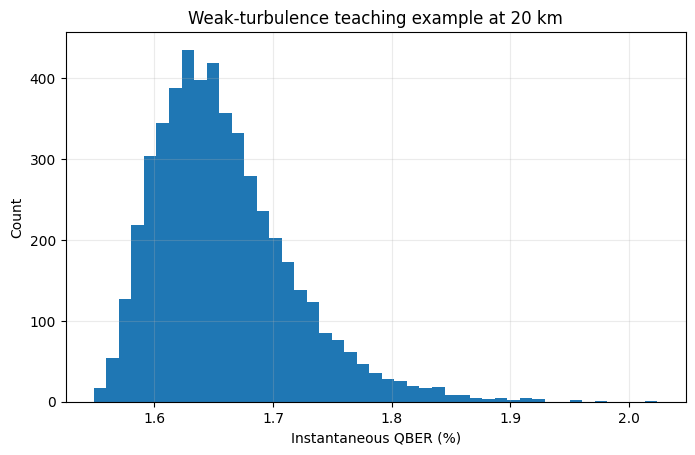

In [9]:
def gain_qber_from_eta(eta, ed=P["bb84_misalignment"]):
    eta = np.asarray(eta, dtype=float)
    mu = P["mu_signal"]
    y0 = P["dark_yield"]
    signal = 1.0 - np.exp(-mu*eta)
    Q = signal + y0
    E = (ed*signal + 0.5*y0) / np.maximum(Q, 1e-30)
    return Q, E

mc_rng = np.random.default_rng(123)
demo_distance = 20.0
base_eta = deterministic_eta(demo_distance)
fading = lognormal_fading(demo_distance, size=5000, rng=mc_rng)
eta_samples = np.clip(base_eta * fading, 0, 1)
_, E_samples = gain_qber_from_eta(eta_samples)

print("20 km deterministic eta:", base_eta)
print("Mean QBER under fading (%):", 100*np.mean(E_samples))
print("95th percentile QBER (%):", 100*np.percentile(E_samples, 95))

plt.figure(figsize=(8, 4.8))
plt.hist(100*E_samples, bins=45)
plt.xlabel("Instantaneous QBER (%)")
plt.ylabel("Count")
plt.title("Weak-turbulence teaching example at 20 km")
plt.grid(True, alpha=0.25)
plt.show()

# Part II — Follow actual bit arrays through Eve, correction, and hashing

Part I answered, “What link behaviour do these FSO assumptions predict?” Part II asks, “What happens to Alice's and Bob's bits during a particular simulated BB84 exchange?”

1. Begin with **2,400 already-detected ideal single-photon signals**. Optical loss is not applied to these signals again.
2. Let Eve intercept a configurable fraction and let the independent channel flip Bob's bits with probability `demo_channel_qber`.
3. Keep Alice/Bob positions with matching bases.
4. Use LDPC parity checks to estimate the errors.
5. If correction succeeds and the teaching budget is positive, compress the corrected key.

The default channel probability here is **2%**, whereas the Part I 20 km model gives about **1.641%**. Both can be correct because they come from different inputs and experiments. Changing the summary distance does not change these generated keys.

Think of the three key stages as **sifted key → reconciled key → final hashed key**. Sifting discards incompatible measurement positions. Reconciliation corrects disagreements while revealing parity information. Privacy amplification reduces the length to address information leakage under an appropriate security analysis.

The simulator can inspect everyone's arrays because it is a teaching program. Real Alice and Bob do not have direct access to each other's undisclosed key or Eve's records. This experiment covers one individual intercept-resend attack, not multiphoton attacks or DPS eavesdropping.

## 8. Understand Eve's intercept-resend attack step by step

A **basis** is a choice of how to prepare or measure a quantum state. This ideal BB84 simulation labels the two choices `Z` and `X` (internally, 0 and 1). Measuring in the preparation basis returns the prepared bit; measuring in the other basis gives a random bit.

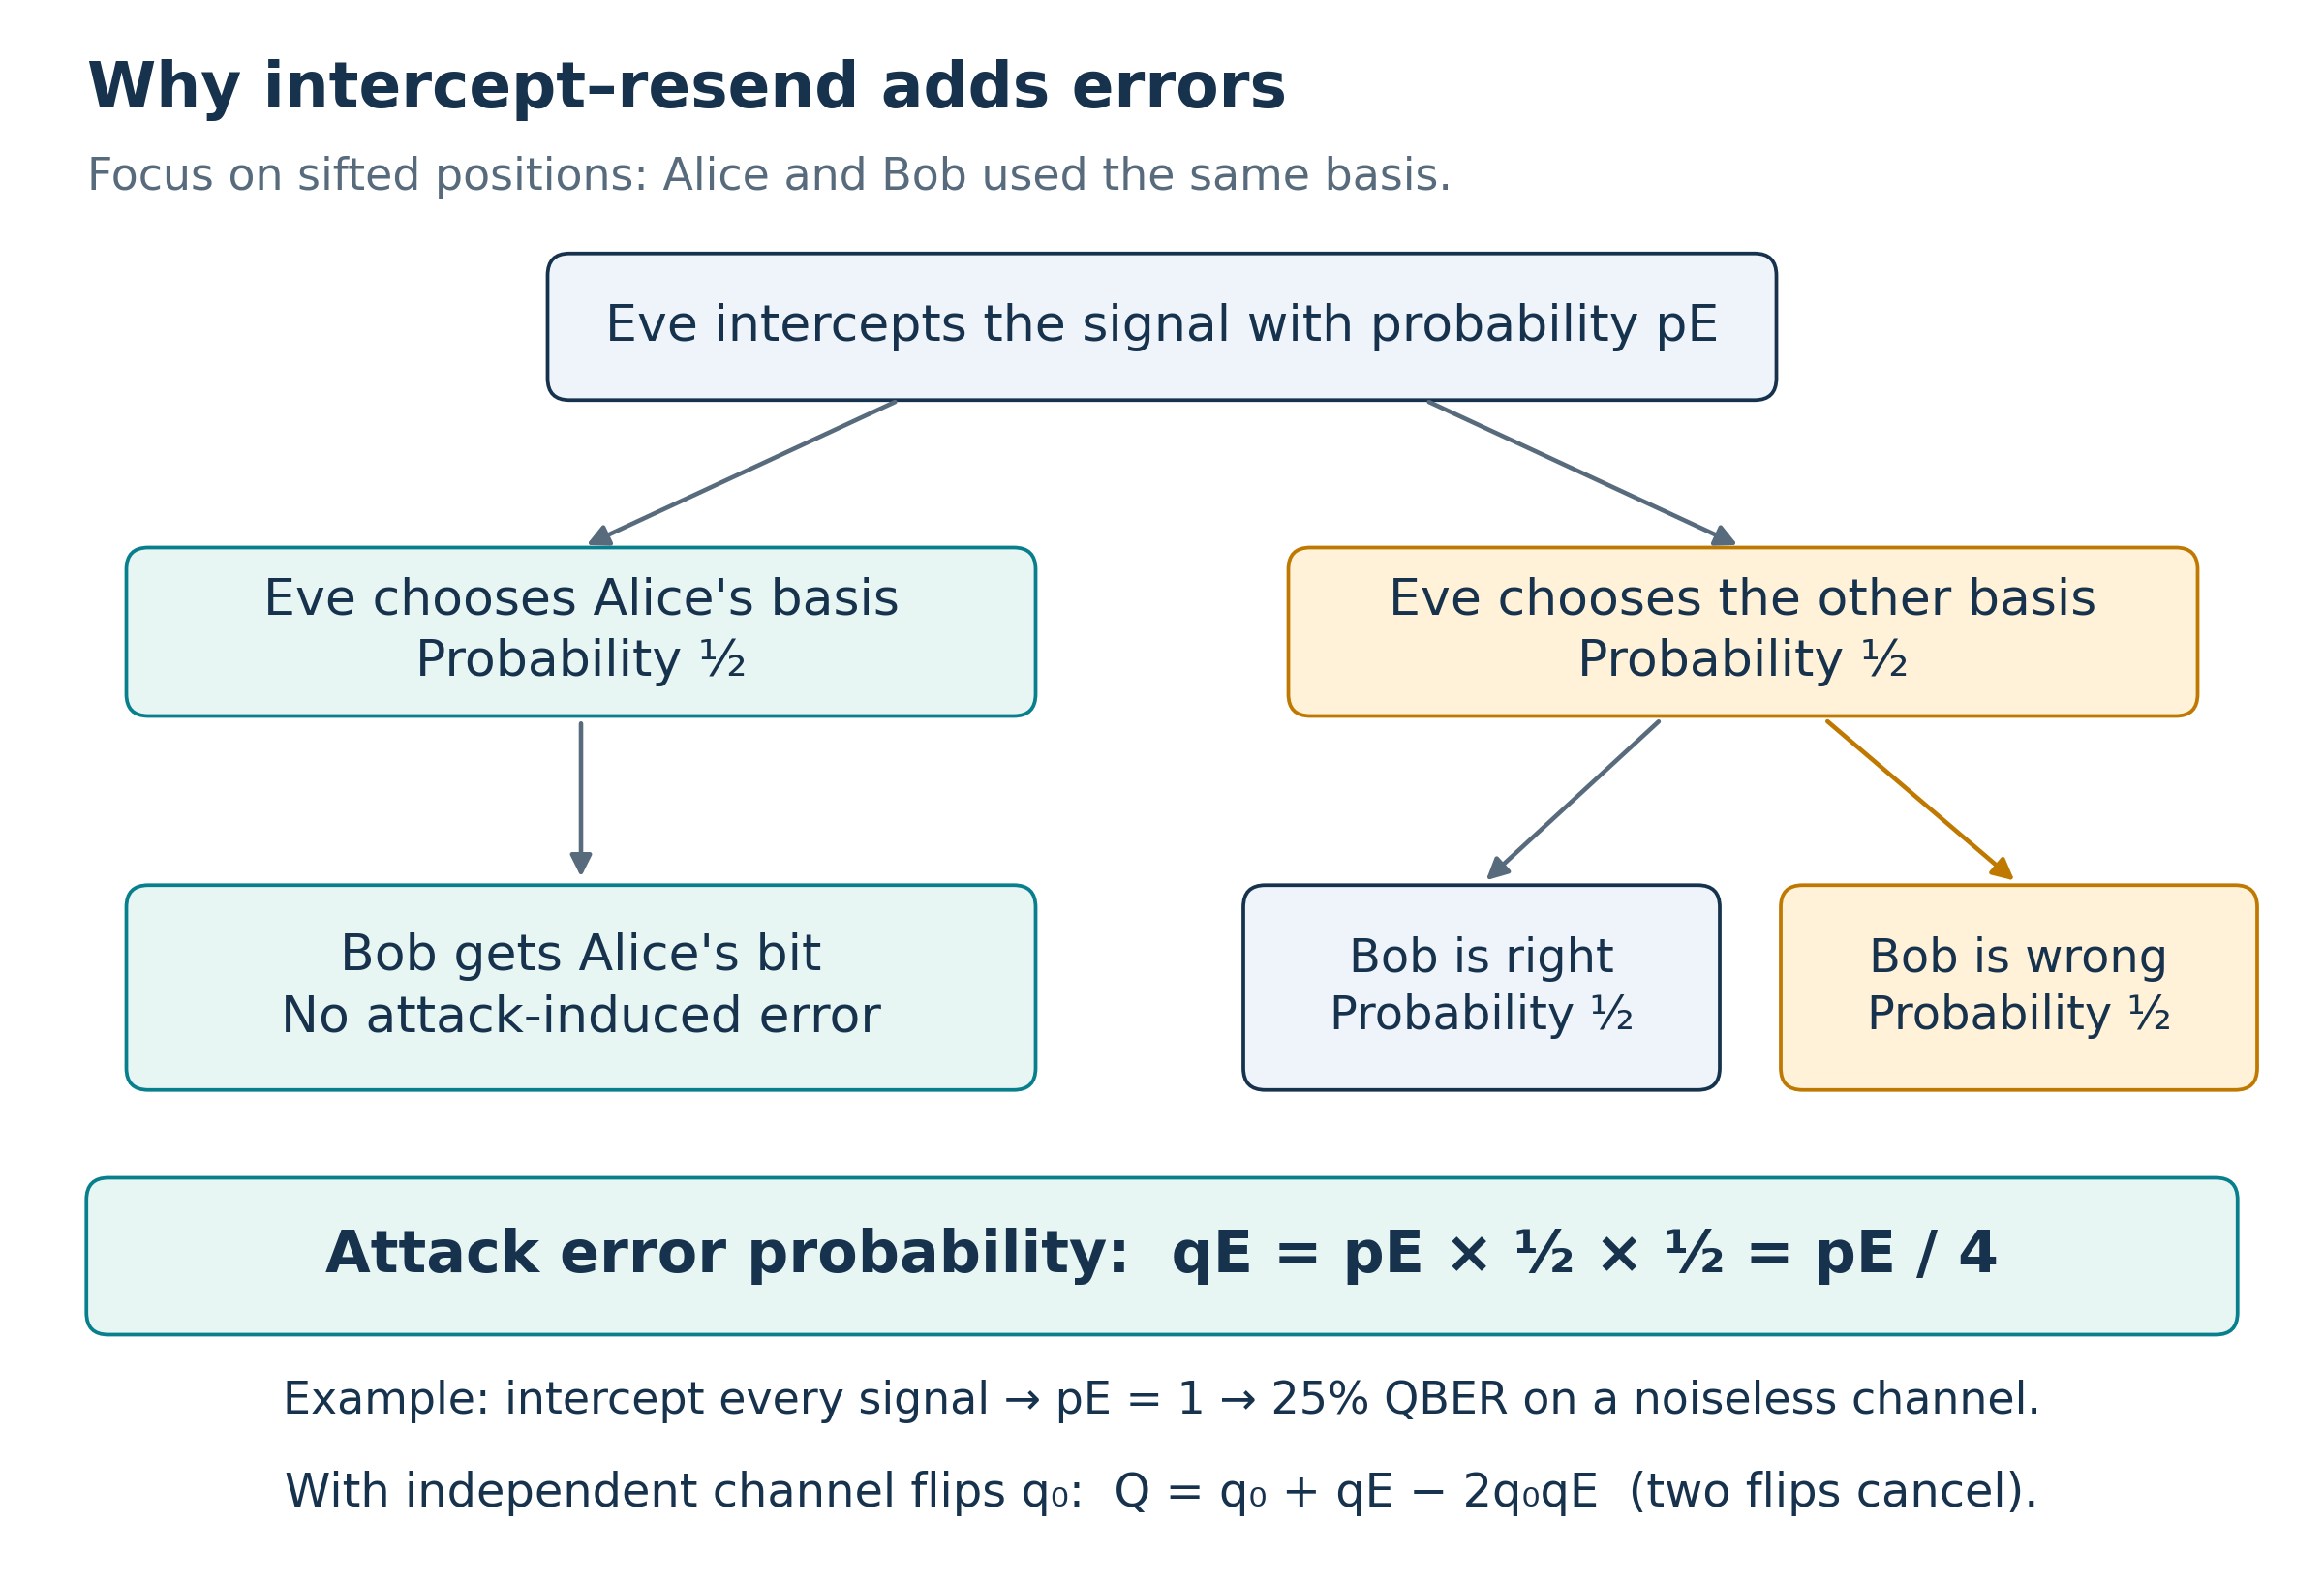

### Follow one signal

1. Alice chooses a random bit and a random basis.
2. Eve intercepts with probability $p_E$. If she does not intercept, Alice's state continues to Bob.
3. If she intercepts, Eve chooses her own random basis and measures. A matching basis gives the correct bit; the other basis gives a random outcome.
4. Eve resends the state described by her basis and outcome.
5. Bob measures in his independently chosen basis.
6. The model applies an independent channel bit flip with probability $q_0$.
7. Alice and Bob announce their bases and keep only matching-basis positions.

NumPy samples these ideal measurement probabilities directly. It does not numerically evolve a physical optical quantum state.

### Why full interception causes 25% errors on a noiseless channel

Consider only the positions Alice and Bob keep. Eve chose the wrong basis half the time. In those cases Bob's result is wrong half the time. Therefore the attack contribution is

$$q_E=p_E\times\frac12\times\frac12=\frac{p_E}{4}.$$

If Eve intercepts every signal, $p_E=1$, so $q_E=0.25$. The fraction is calculated among sifted bits; mismatched Alice/Bob bases have already been removed.

### Combine Eve's disturbance with channel errors

Two flips at one position cancel. A final error occurs when exactly one source flips the bit:

$$Q=q_0(1-q_E)+(1-q_0)q_E=q_0+q_E-2q_0q_E.$$

With the defaults, $p_E=0.08$, $q_E=0.02$, and $q_0=0.02$. Thus

$$Q=0.02+0.02-2(0.02)(0.02)=0.0392=3.92\%.$$

This is an expectation, so a finite sample can differ. Full interception with the same 2% channel noise has expected QBER 26%, rather than the noiseless 25% example.

### What does Eve know?

After basis announcement, Eve knows which intercepted positions used Alice's basis. She knows those Alice bits exactly. The expected fraction of all sifted Alice bits known this way is $p_E/2$, or **4%** for 8% interception. This describes her direct knowledge **before syndrome exchange**. Guessing a bit correctly by chance is not the same as knowing it.

**Read the sweep:** the first following cell defines the simulator; the second runs 100,000 signals at each attack fraction. In the left plot compare observed QBER points with the expectation line. In the right plot compare Eve's known fraction with $p_E/2$. Small gaps are sampling variation. The vertical dotted marker identifies the selected default attack. QBER detects disturbance but cannot, by itself, identify whether the cause is Eve or ordinary noise.

In [10]:
def simulate_bb84_intercept_resend(n_signals, intercept_fraction, channel_qber=0.0, seed=11):
    # Exact sampling of ideal Z/X-basis measurement probabilities.
    if isinstance(n_signals, (bool, np.bool_)) or not isinstance(n_signals, (int, np.integer)) or n_signals < 1:
        raise ValueError("n_signals must be a positive integer")
    if not np.isfinite(intercept_fraction) or not 0.0 <= intercept_fraction <= 1.0:
        raise ValueError("intercept_fraction must be between 0 and 1")
    if not np.isfinite(channel_qber) or not 0.0 <= channel_qber <= 0.5:
        raise ValueError("channel_qber must be between 0 and 0.5")

    attack_rng = np.random.default_rng(seed)
    alice_bits = attack_rng.integers(0, 2, n_signals, dtype=np.uint8)
    alice_bases = attack_rng.integers(0, 2, n_signals, dtype=np.uint8)
    bob_bases = attack_rng.integers(0, 2, n_signals, dtype=np.uint8)
    eve_bases = attack_rng.integers(0, 2, n_signals, dtype=np.uint8)
    intercepted = attack_rng.random(n_signals) < intercept_fraction

    eve_random = attack_rng.integers(0, 2, n_signals, dtype=np.uint8)
    eve_measured = np.where(eve_bases == alice_bases, alice_bits, eve_random)
    arriving_bits = np.where(intercepted, eve_measured, alice_bits)
    arriving_bases = np.where(intercepted, eve_bases, alice_bases)
    bob_random = attack_rng.integers(0, 2, n_signals, dtype=np.uint8)
    bob_measured = np.where(bob_bases == arriving_bases, arriving_bits, bob_random)
    channel_errors = (attack_rng.random(n_signals) < channel_qber).astype(np.uint8)
    bob_bits = bob_measured ^ channel_errors
    bob_no_eve = np.where(bob_bases == alice_bases, alice_bits, bob_random) ^ channel_errors

    sift_mask = alice_bases == bob_bases
    eve_measurements = np.where(intercepted, eve_measured.astype(np.int8), -1)
    eve_known = intercepted & (eve_bases == alice_bases)
    attack_qber = intercept_fraction / 4.0
    return {
        "alice_bits": alice_bits,
        "alice_bases": alice_bases,
        "bob_bases": bob_bases,
        "eve_bases": eve_bases,
        "intercepted": intercepted,
        "eve_measurements": eve_measurements,
        "sift_mask": sift_mask,
        "alice_key": alice_bits[sift_mask],
        "bob_key": bob_bits[sift_mask],
        "bob_no_eve_key": bob_no_eve[sift_mask],
        "sifted_intercepted": intercepted[sift_mask],
        "eve_sifted_measurements": eve_measurements[sift_mask],
        "eve_known_mask": eve_known[sift_mask],
        "expected_qber": channel_qber + attack_qber - 2*channel_qber*attack_qber,
    }


Eve intercept (%) | QBER observed (%) | QBER expected (%) | Eve knows (%)
              0.0 |             2.029 |             2.000 |         0.000
              8.0 |             4.014 |             3.920 |         3.958
             10.0 |             4.485 |             4.400 |         4.858
             20.0 |             6.889 |             6.800 |         9.881
             30.0 |             9.286 |             9.200 |        14.844
             40.0 |            11.722 |            11.600 |        19.880
             50.0 |            14.092 |            14.000 |        24.801
             60.0 |            16.548 |            16.400 |        29.868
             70.0 |            18.950 |            18.800 |        34.832
             80.0 |            21.250 |            21.200 |        39.849
             90.0 |            23.592 |            23.600 |        44.756
            100.0 |            25.962 |            26.000 |        49.941


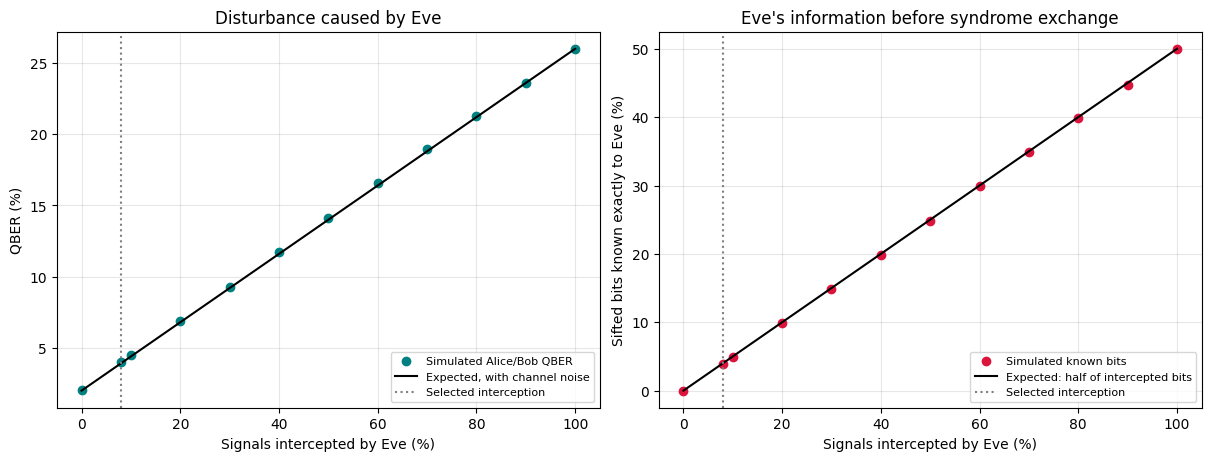

In [11]:
eve_fractions = np.unique(np.r_[np.linspace(0, 1, 11), P["eve_intercept_fraction"]])
eve_qbers, eve_known_fractions = [], []
for fraction in eve_fractions:
    trial = simulate_bb84_intercept_resend(
        100_000, fraction, P["demo_channel_qber"], seed=23
    )
    eve_qbers.append(np.mean(trial["alice_key"] != trial["bob_key"]))
    eve_known_fractions.append(np.mean(trial["eve_known_mask"]))
eve_qbers = np.asarray(eve_qbers)
eve_known_fractions = np.asarray(eve_known_fractions)
expected_qbers = P["demo_channel_qber"] + eve_fractions/4 - 2*P["demo_channel_qber"]*eve_fractions/4

print("Eve intercept (%) | QBER observed (%) | QBER expected (%) | Eve knows (%)")
for fraction, measured, expected, known in zip(eve_fractions, eve_qbers, expected_qbers, eve_known_fractions):
    print(f"{100*fraction:17.1f} | {100*measured:17.3f} | {100*expected:17.3f} | {100*known:13.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(100*eve_fractions, 100*eve_qbers, 'o', color='teal', label='Simulated Alice/Bob QBER')
axes[0].plot(100*eve_fractions, 100*expected_qbers, color='black', label='Expected, with channel noise')
axes[0].set_ylabel("QBER (%)")
axes[0].set_title("Disturbance caused by Eve")
axes[1].plot(100*eve_fractions, 100*eve_known_fractions, 'o', color='crimson', label='Simulated known bits')
axes[1].plot(100*eve_fractions, 50*eve_fractions, color='black', label='Expected: half of intercepted bits')
axes[1].set_ylabel("Sifted bits known exactly to Eve (%)")
axes[1].set_title("Eve's information before syndrome exchange")
for ax in axes:
    ax.axvline(100*P["eve_intercept_fraction"], color='gray', linestyle=':', label='Selected interception')
    ax.set_xlabel("Signals intercepted by Eve (%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
plt.show()


## 9. Sift the keys and count the disagreements

**Purpose:** produce the smaller bit arrays used by the LDPC demonstration. Here the sample size is 2,400, rather than the 100,000 signals used for each point in the previous sweep.

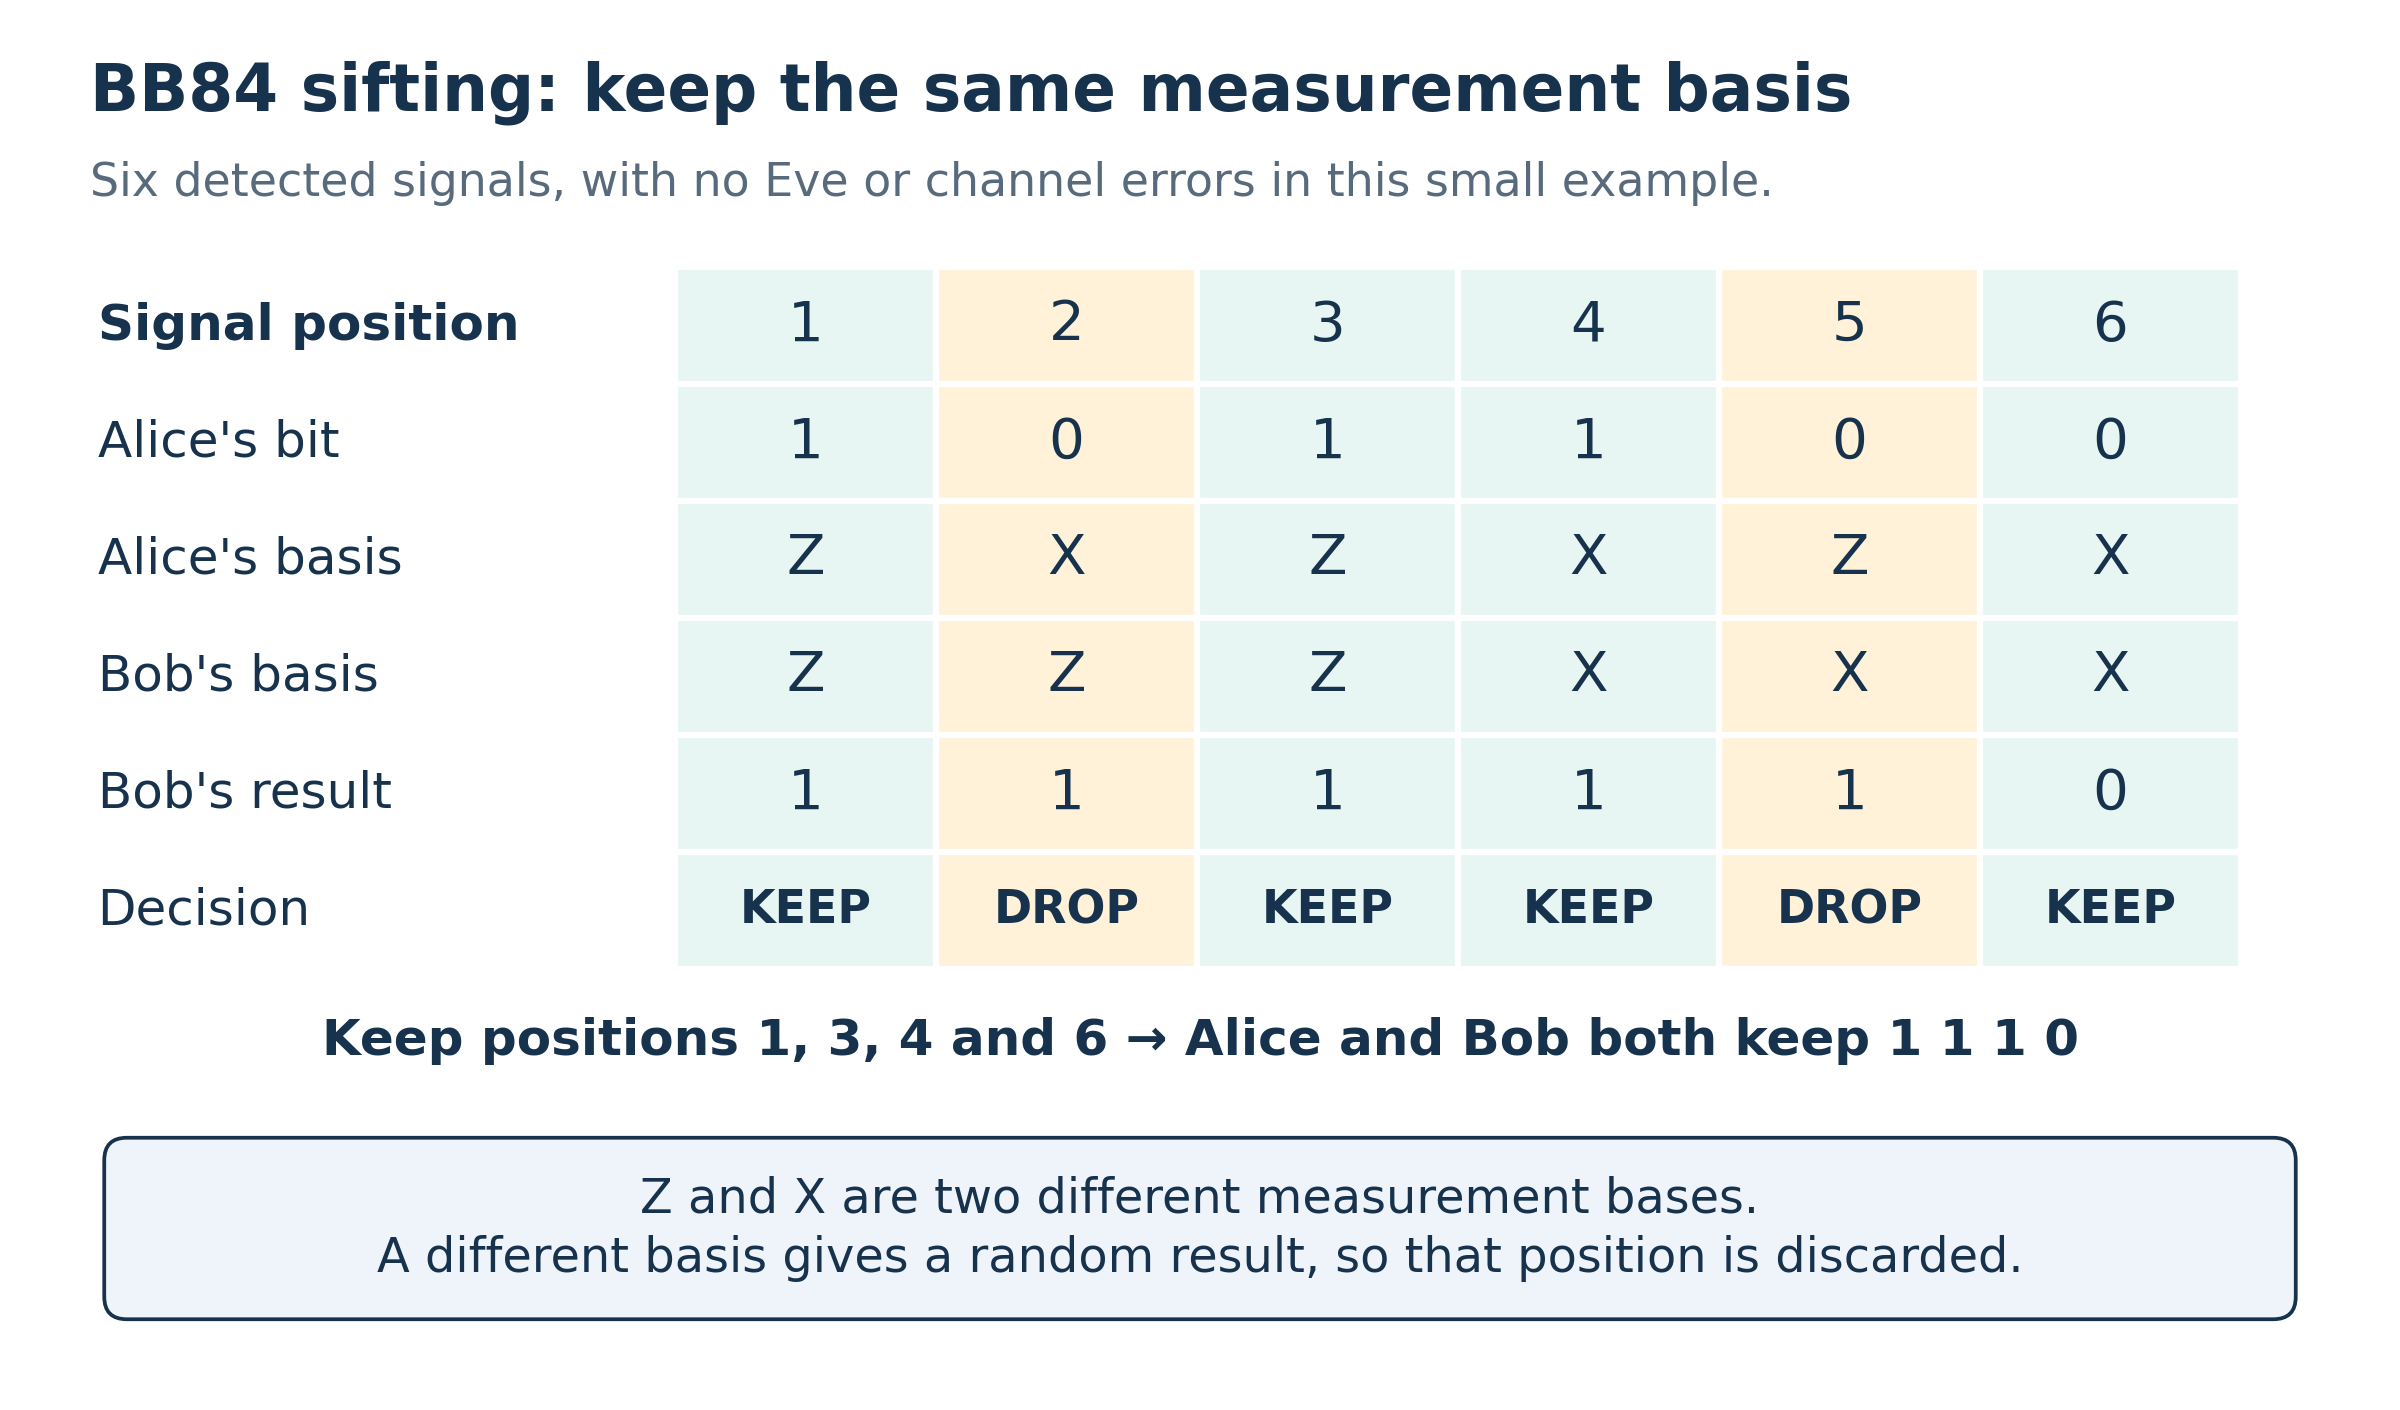

### Step 1 — Keep positions with matching bases

`sift_mask = alice_bases == bob_bases` is a list of keep/discard decisions. Alice and Bob apply the same mask, so their sifted arrays refer to the same signal positions. Matching bases happen about half the time, but a particular finite run need not keep exactly half.

The public announcement gives bases, not the secret bit values. Eve uses this announcement to interpret her stored measurements too.

### Step 2 — Compare corresponding sifted bits

`error_pattern = alice_key ^ bob_key` applies **XOR**, also called addition modulo 2. Equal bits give zero; different bits give one:

| Alice | Bob | XOR / error indicator |
|---:|---:|---:|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

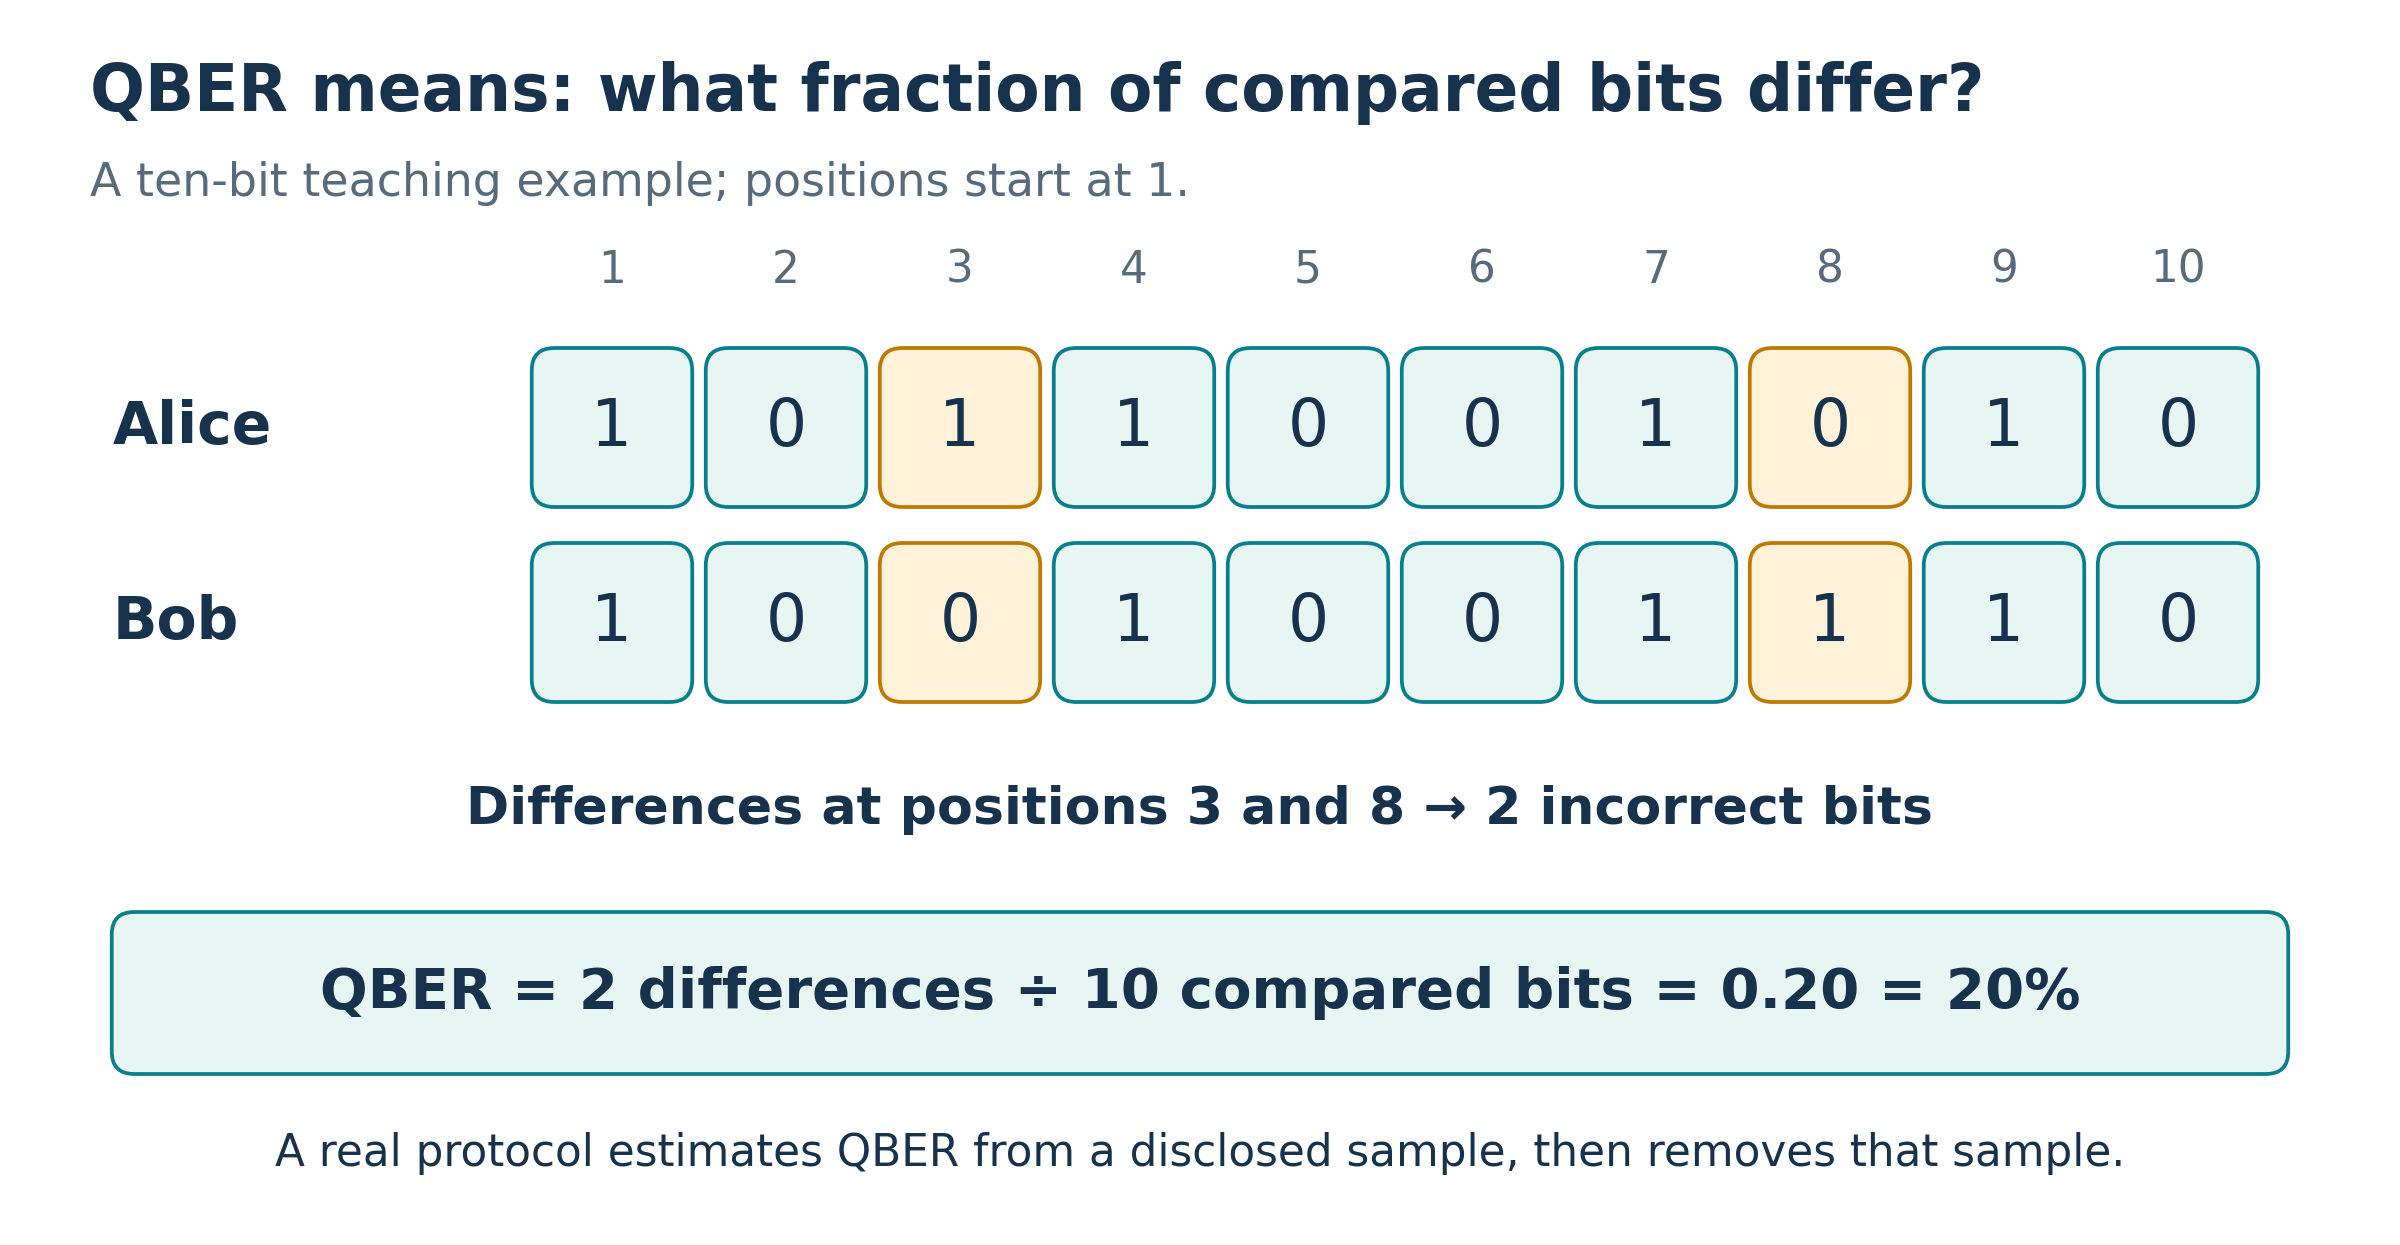

Then $QBER=\text{number of ones in error pattern}/\text{sifted length}$. In the supplied seeded run, **1,197** bits survive and **48** disagree:

$$QBER=48/1197\approx0.04010=4.010\%.$$

### Step 3 — Read the printed previews

`Alice` and `Bob` display corresponding sifted bits before correction. In `Eve measurements`, `-` means she did not intercept that signal. In `Eve known bits`, `?` means she does not know Alice's bit; it does not necessarily mean her measurement differed from it. Position indices start at zero.

The default run counts **40 of 1,197** sifted bits as exactly known to Eve before public syndrome information. The no-Eve comparison uses the same channel-error draws and gives about **2.339%** QBER. It helps isolate the effect of the attack in this sample; neither observed percentage must equal its theoretical expectation exactly.

### What a real protocol would do differently

This program compares complete keys to expose simulation ground truth, and later gives that measured QBER to the decoder. A real protocol would estimate errors from a publicly disclosed sample, remove the disclosed bits, and include estimation uncertainty in its security analysis. Those extra steps are not implemented here.

In [12]:
N_SIGNALS = 2400
DEMO_CHANNEL_QBER = P["demo_channel_qber"]
EVE_INTERCEPT_FRACTION = P["eve_intercept_fraction"]
eve_run = simulate_bb84_intercept_resend(
    N_SIGNALS, EVE_INTERCEPT_FRACTION, DEMO_CHANNEL_QBER, seed=SEED
)

alice_key = eve_run["alice_key"]
bob_key = eve_run["bob_key"]
N_KEY = len(alice_key)
error_pattern = alice_key ^ bob_key
observed_qber = float(np.mean(error_pattern))
no_eve_qber = float(np.mean(alice_key != eve_run["bob_no_eve_key"]))
eve_known_bits = int(eve_run["eve_known_mask"].sum())

print("Detected signals before sifting:", N_SIGNALS)
print("Sifted key length:", N_KEY)
print(f"Eve intercept setting: {100*EVE_INTERCEPT_FRACTION:.1f}%")
print("Intercepted signals / sifted bits:",
      int(eve_run["intercepted"].sum()), "/", int(eve_run["sifted_intercepted"].sum()))
print(f"QBER without Eve (same channel noise): {100*no_eve_qber:.3f}%")
print(f"QBER with Eve (expected / observed): {100*eve_run['expected_qber']:.3f}% / {100*observed_qber:.3f}%")
print("Number of wrong bits at Bob:", int(error_pattern.sum()))
print(f"Sifted bits known exactly to Eve before syndrome exchange: {eve_known_bits} / {N_KEY}")

preview = min(48, N_KEY)
print("\nFirst sifted bits, before reconciliation:")
print("Alice:            ", ''.join(map(str, alice_key[:preview].tolist())))
print("Bob:              ", ''.join(map(str, bob_key[:preview].tolist())))
print("Eve measurements: ", ''.join('-' if bit < 0 else str(bit)
                                  for bit in eve_run["eve_sifted_measurements"][:preview]))
print("Eve known bits:   ", ''.join(str(bit) if known else '?'
                                  for bit, known in zip(eve_run["eve_sifted_measurements"][:preview],
                                                        eve_run["eve_known_mask"][:preview])))

intercepted_positions = np.flatnonzero(eve_run["sifted_intercepted"])[:8]
if len(intercepted_positions):
    sifted_alice_bases = eve_run["alice_bases"][eve_run["sift_mask"]]
    sifted_eve_bases = eve_run["eve_bases"][eve_run["sift_mask"]]
    print("\nFirst intercepted sifted positions (zero-based):")
    print("Index | Alice basis | Eve basis | Alice | Bob | Eve outcome | Eve knows")
    for i in intercepted_positions:
        a_basis, e_basis = 'ZX'[sifted_alice_bases[i]], 'ZX'[sifted_eve_bases[i]]
        known = 'yes' if eve_run["eve_known_mask"][i] else 'no'
        print(f"{i:5d} | {a_basis:^11} | {e_basis:^9} | {alice_key[i]:5d} | {bob_key[i]:3d} | {eve_run['eve_sifted_measurements'][i]:11d} | {known}")


Detected signals before sifting: 2400
Sifted key length: 1197
Eve intercept setting: 8.0%
Intercepted signals / sifted bits: 190 / 88
QBER without Eve (same channel noise): 2.339%
QBER with Eve (expected / observed): 3.920% / 4.010%
Number of wrong bits at Bob: 48
Sifted bits known exactly to Eve before syndrome exchange: 40 / 1197

First sifted bits, before reconciliation:
Alice:             010011001110100110101011010110001110111000001000
Bob:               010011011110100110101011110110001110111100001000
Eve measurements:  -------------------------------------0----------
Eve known bits:    ????????????????????????????????????????????????

First intercepted sifted positions (zero-based):
Index | Alice basis | Eve basis | Alice | Bob | Eve outcome | Eve knows
   37 |      X      |     Z     |     1 |   1 |           0 | no
   54 |      Z      |     Z     |     1 |   1 |           1 | yes
   55 |      Z      |     Z     |     0 |   1 |           0 | yes
   59 |      X      |     X     

## 10. Build parity checks: the basic idea behind LDPC

**Purpose:** describe constraints that help Bob infer which bits are wrong without Alice sending her full key. A parity is the sum of selected bits modulo 2: even sums give 0; odd sums give 1.

The matrix $H$ has $m$ rows and $n$ columns. A column represents one key bit. A row represents one parity check. An entry of 1 means that bit participates in that check; 0 means it does not. “Low density” means only a small fraction of all possible entries are 1.

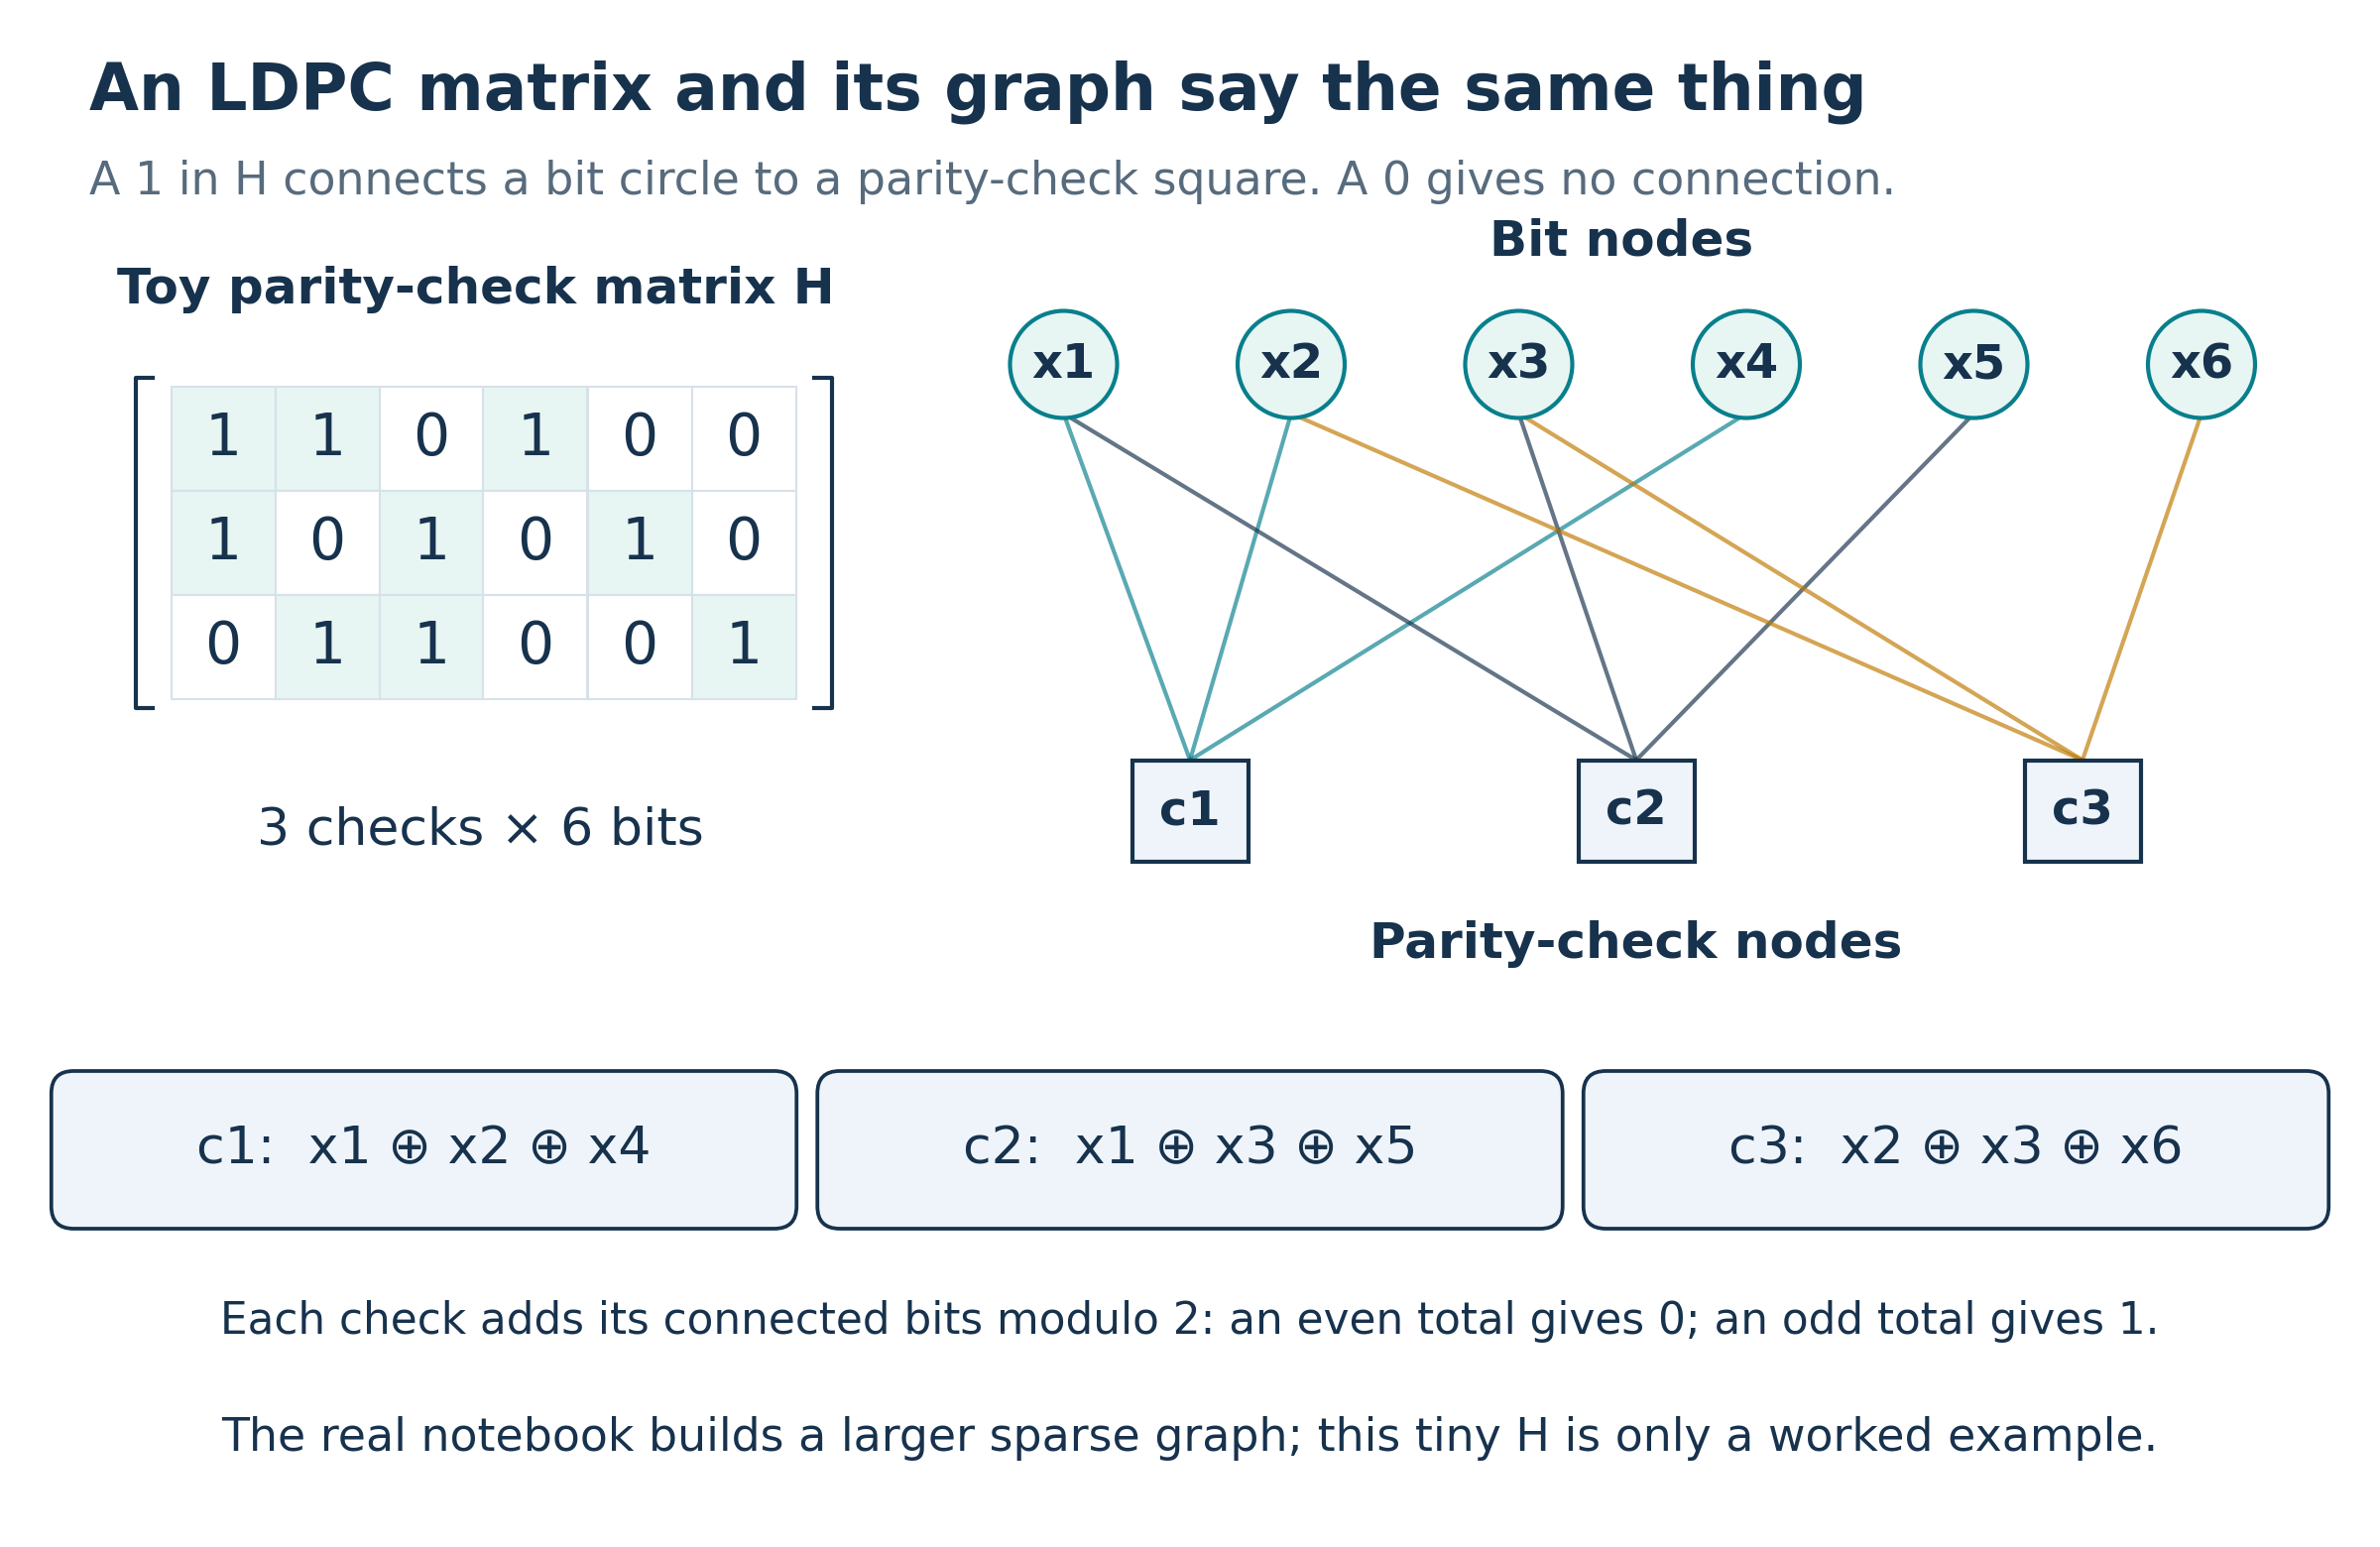

### A small example you can calculate by hand

Use six bits and three checks:

$$H=\begin{bmatrix}1&1&0&1&0&0\\1&0&1&0&1&0\\0&1&1&0&0&1\end{bmatrix},\qquad x_A=(1,0,1,1,0,0).$$

1. Check 1 selects bits 1, 2, and 4: $1+0+1=2$, so its parity is 0.
2. Check 2 selects bits 1, 3, and 5: $1+1+0=2$, so its parity is 0.
3. Check 3 selects bits 2, 3, and 6: $0+1+0=1$, so its parity is 1.

Alice's syndrome is therefore **001**. These example positions count from one, unlike the zero-based Python indices printed earlier.

Alice's list of parity results is her **syndrome**:

$$s_A=Hx_A^T\pmod2.$$

Here $x_A$ is Alice's bit vector, and $T$ means write it as a column for matrix multiplication. A syndrome is a short summary of parities; it is not a copy of the key and it need not be all zeros. This is syndrome reconciliation of an arbitrary key, not an assumption that Alice's key is a preselected codeword.

### How the code represents the larger matrix

1. Make one variable node for each of the `N_KEY` sifted bits.
2. Make `M_CHECKS = N_KEY // 2` check nodes; `//` means integer division.
3. Connect each bit to three different checks and keep check sizes roughly balanced.
4. Store the graph edges instead of constructing a large dense array of zeros.
5. Calculate a check's syndrome by summing its connected bits modulo 2.

In the default run, $n=1197$, $m=598$, and there are $1197\times3=3591$ edges. The check degrees range from 5 to 7. Degree simply means the number of connections to a node.

The printed code rate $1-m/n\approx0.5004$ is **nominal**. The exact dimension depends on the rank of $H$. This is a small, generated teaching graph, not an optimized standardized LDPC design. The miniature diagram explains the mechanism; it is not the actual randomly generated 1,197-bit graph.

In [13]:
def make_sparse_ldpc_graph(n=1200, m=600, column_weight=3, seed=7):
    rng_local = np.random.default_rng(seed)
    row_counts = np.zeros(m, dtype=int)
    edge_checks, edge_vars = [], []

    # Keep rows roughly balanced while giving every variable 'column_weight' checks.
    for i in range(n):
        candidates = np.argsort(row_counts)[:max(30, column_weight*12)]
        rows = rng_local.choice(candidates, size=column_weight, replace=False)
        for j in rows:
            edge_checks.append(int(j))
            edge_vars.append(i)
            row_counts[j] += 1

    edge_checks = np.asarray(edge_checks, dtype=int)
    edge_vars = np.asarray(edge_vars, dtype=int)
    check_edges = [np.flatnonzero(edge_checks == j) for j in range(m)]
    var_edges = [np.flatnonzero(edge_vars == i) for i in range(n)]
    return edge_checks, edge_vars, check_edges, var_edges, row_counts


def syndrome_from_graph(bits, check_edges, edge_vars):
    s = np.zeros(len(check_edges), dtype=np.uint8)
    for j, edges in enumerate(check_edges):
        s[j] = int(bits[edge_vars[edges]].sum() % 2)
    return s

M_CHECKS = N_KEY // 2
edge_checks, edge_vars, check_edges, var_edges, row_counts = make_sparse_ldpc_graph(
    n=N_KEY, m=M_CHECKS, column_weight=3, seed=7
)

print("n =", N_KEY, "m =", M_CHECKS, "nominal code rate ~", 1-M_CHECKS/N_KEY)
print("Number of graph edges =", len(edge_vars))
print("Check-node degree range =", row_counts.min(), "to", row_counts.max())

n = 1197 m = 598 nominal code rate ~ 0.5004177109440268
Number of graph edges = 3591
Check-node degree range = 5 to 7


## 11. Exchange syndromes and let Bob estimate the errors

**Purpose:** turn parity disagreements into a likely error pattern, then flip those positions in Bob's key.

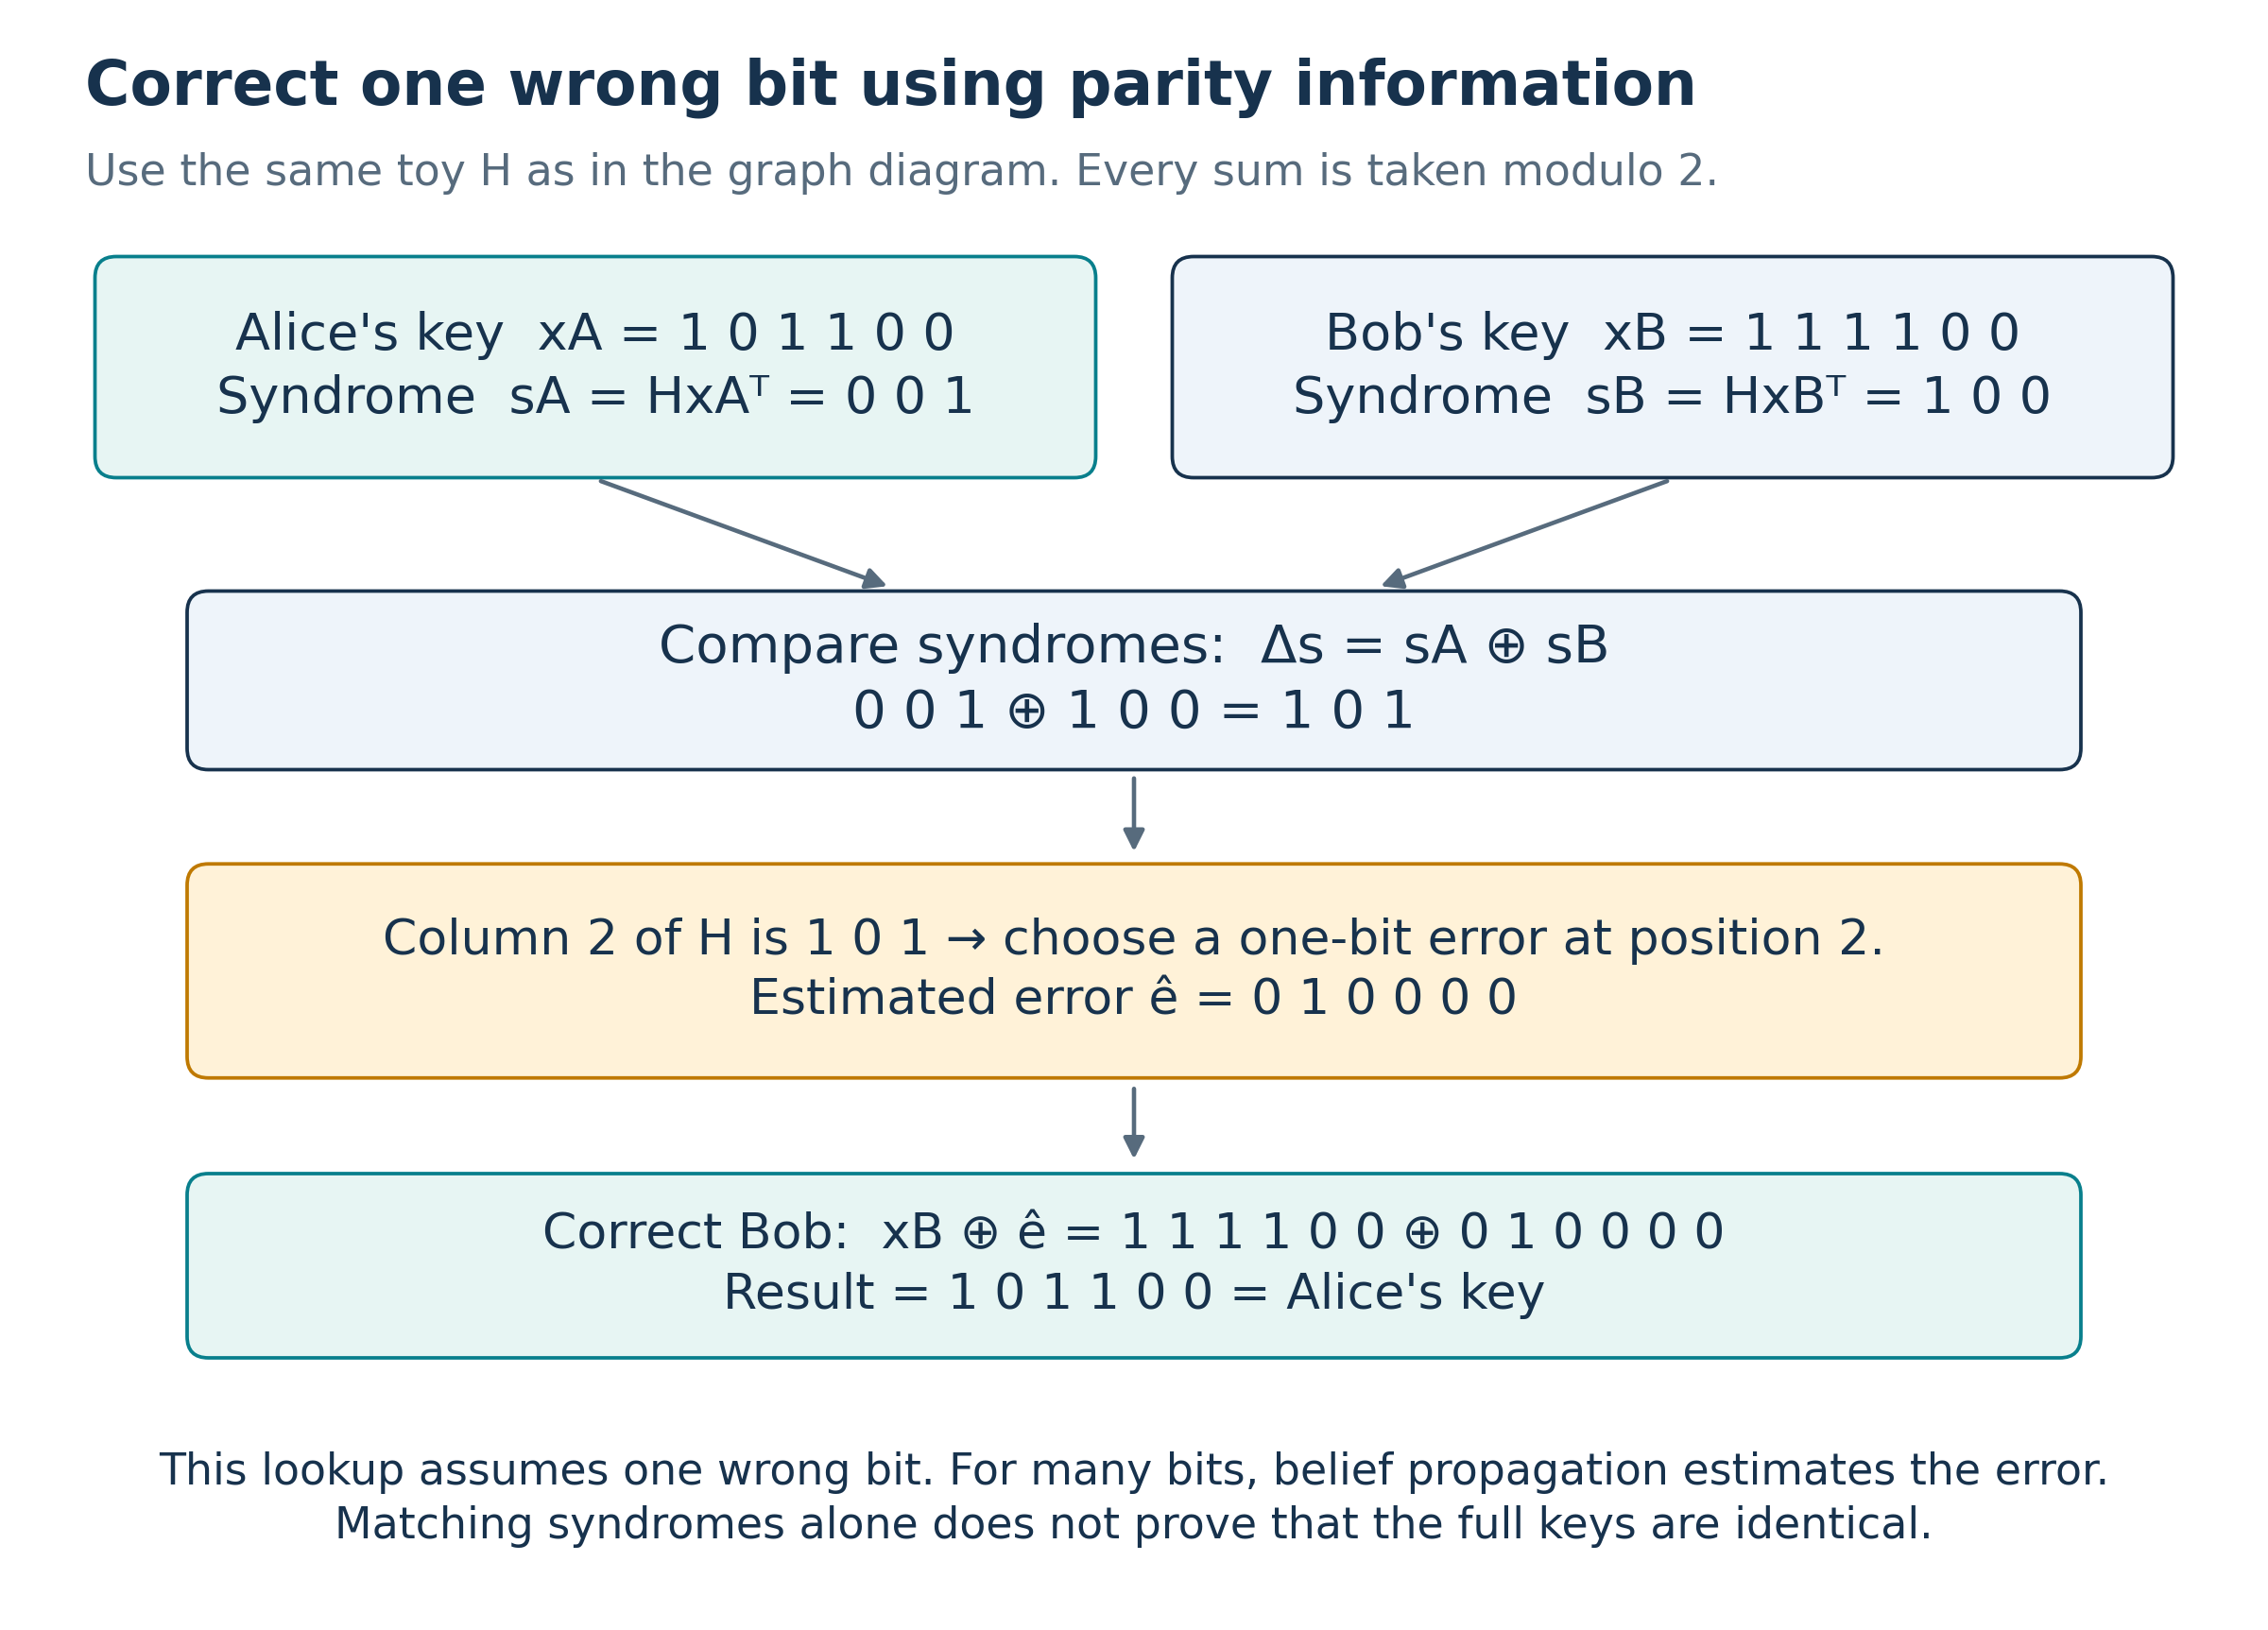

### Step 1 — Compare the parity summaries

Alice sends $s_A$. Bob calculates $s_B=Hx_B^T\pmod2$ locally. XOR gives

$$\Delta s=s_A\oplus s_B=H(x_A\oplus x_B)^T=He^T.$$

The vector $e=x_A\oplus x_B$ marks the true error positions. Bob does not know $e$; he knows only the parity constraints $\Delta s$. An odd number of errors in a check changes its parity; an even number does not.

In the six-bit example, Alice has **101100**, Bob has **111100**, and the true error is **010000**: only bit 2 is wrong. Alice's syndrome is **001**; Bob's is **100**. Their XOR is **101**, which matches column 2 of $H$. Under a single-error assumption, this identifies bit 2. Flipping it gives $111100\oplus010000=101100$. The larger decoder must infer potentially many errors; it cannot simply look up one column.

### Step 2 — Start with a probability for each error

The decoder receives `crossover_p`, here the observed QBER. It starts with the log-likelihood ratio

$$LLR=\ln\frac{1-p}{p}.$$

Positive means “no error is more likely”; negative means “an error is more likely.” At $p=0.04$, the prior LLR is $\ln24\approx3.178$. The decoder initially prefers leaving each bit alone.

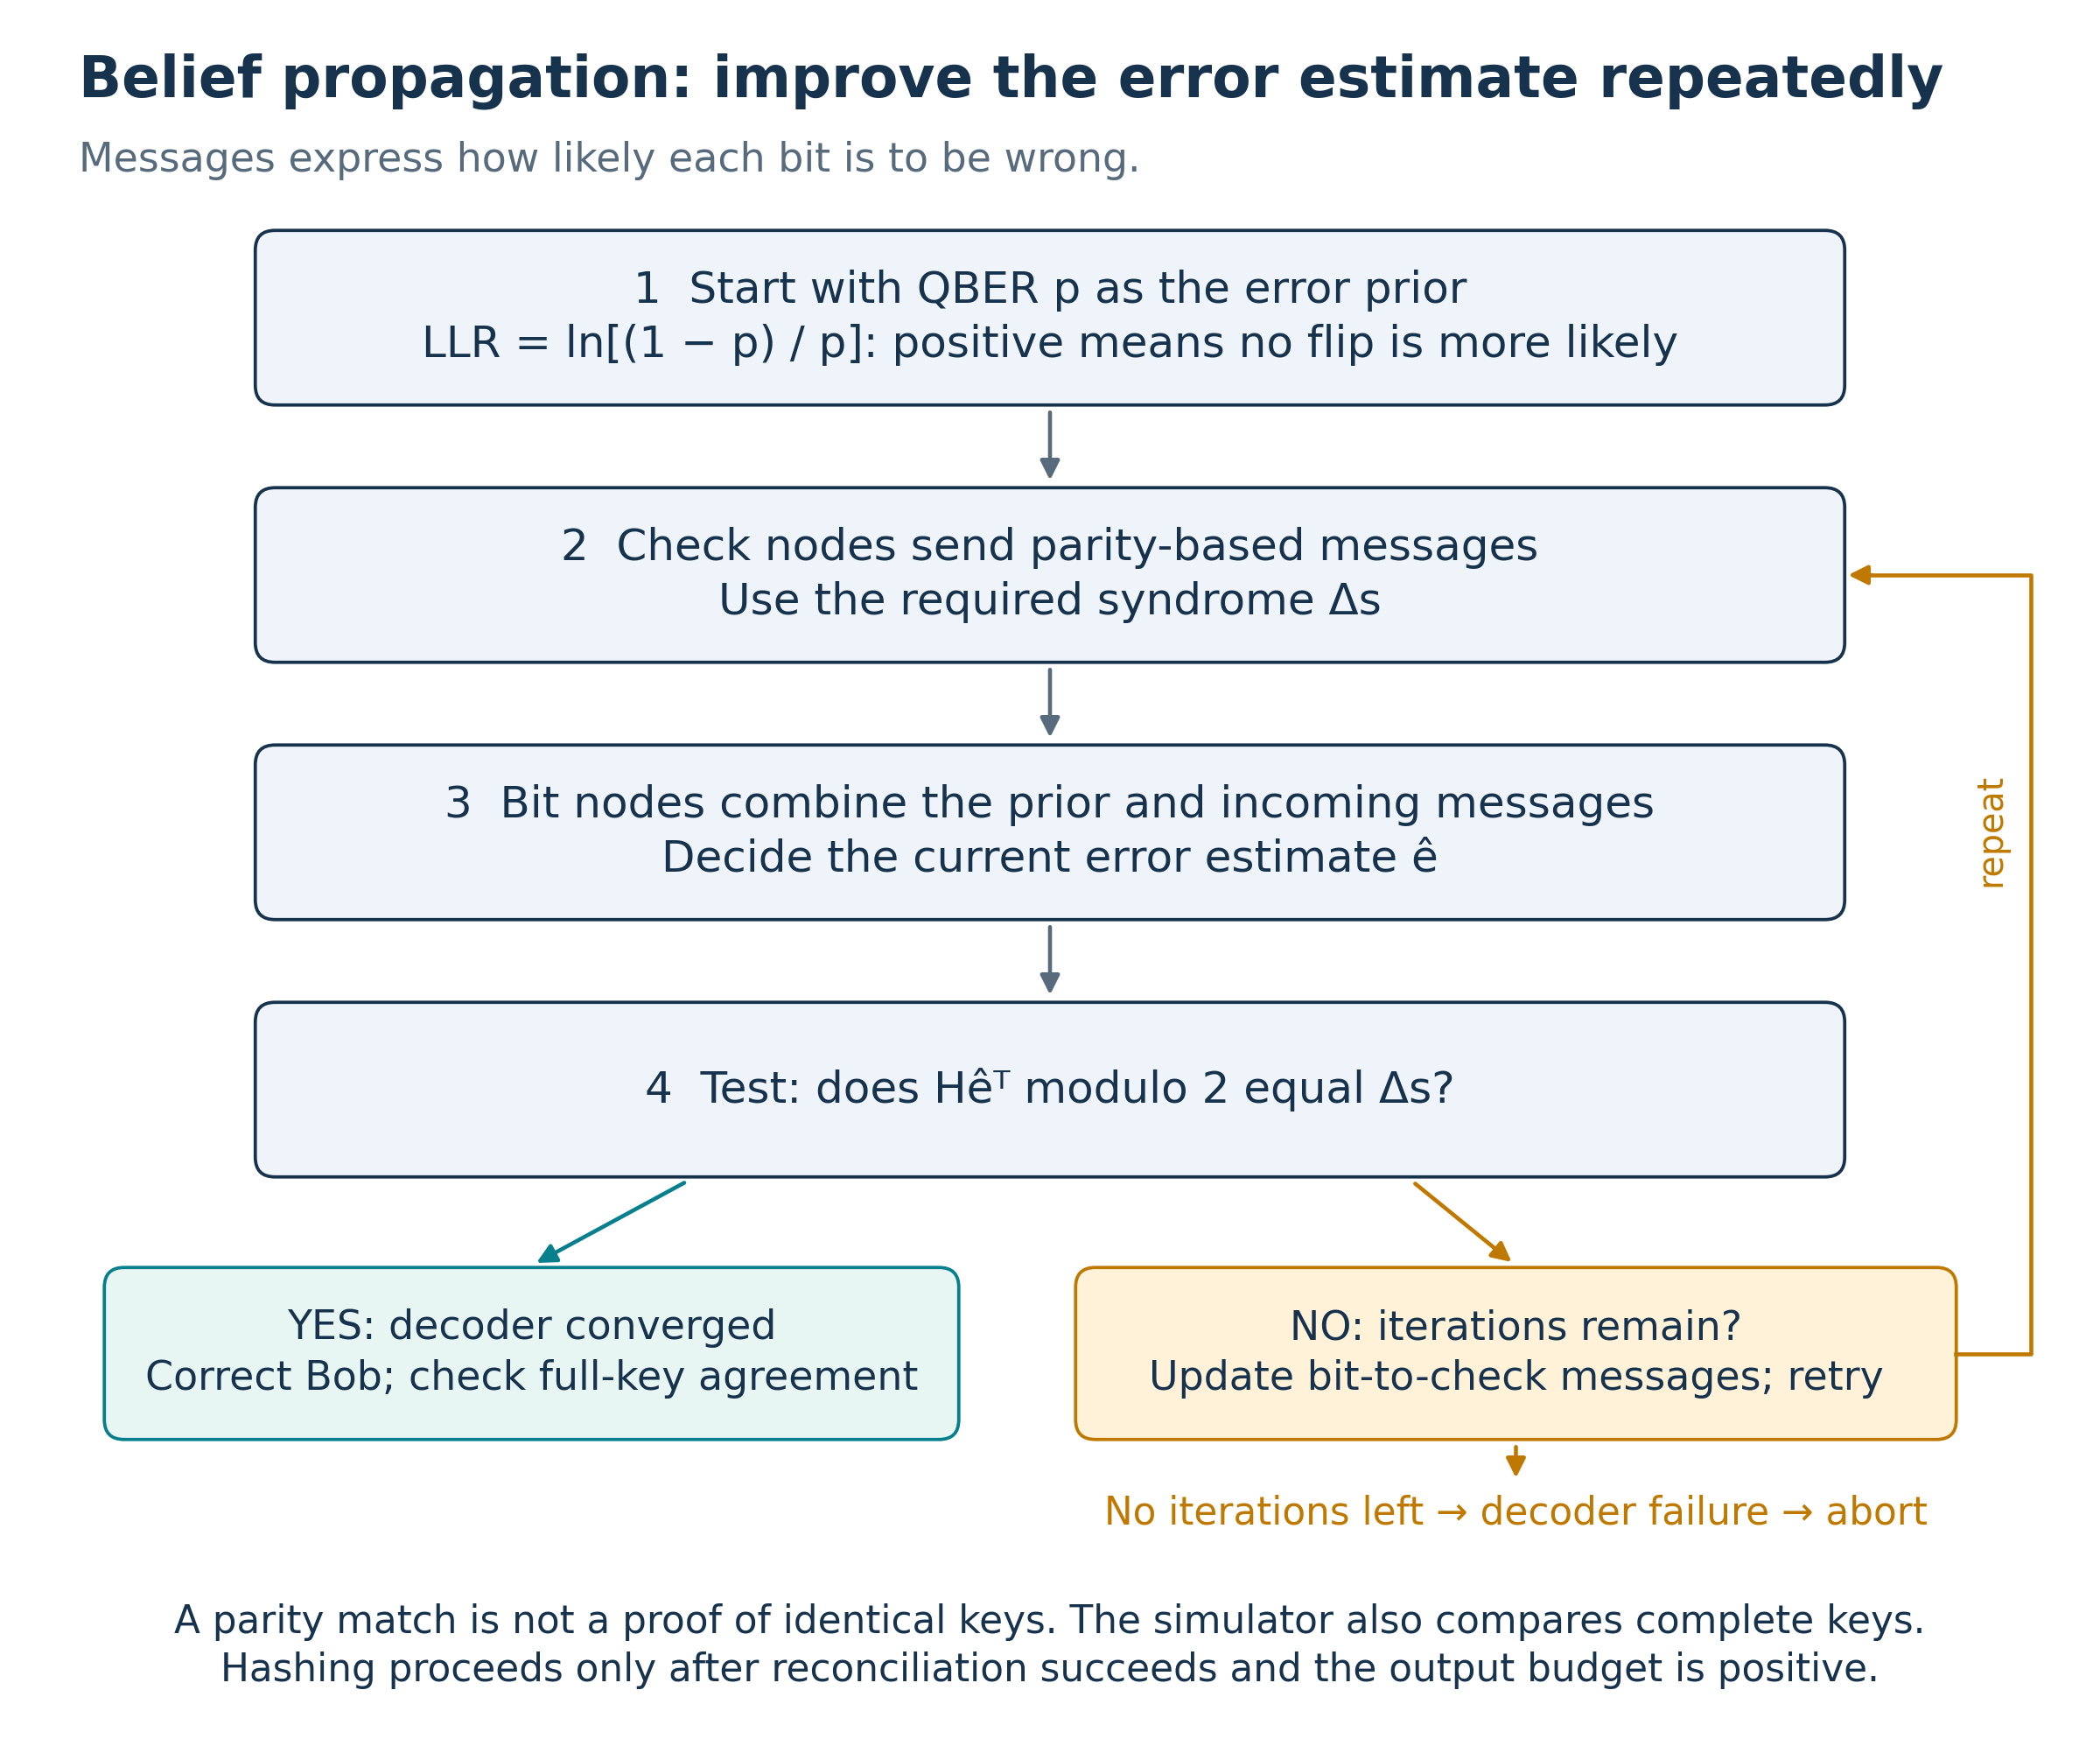

### Step 3 — Repeat the belief-propagation loop

1. **Checks send messages:** each check combines its other connected bits' current beliefs with its required parity. A target syndrome bit of 1 changes the parity sign.
2. **Bits combine messages:** each bit adds incoming check messages to its prior LLR.
3. **Make a trial decision:** a negative total LLR becomes an estimated error bit of 1; otherwise it is 0.
4. **Test the syndrome:** if the estimated error produces $\Delta s$, report convergence.
5. **If needed, send updated bit messages:** exclude the recipient check's own previous contribution, then start the next iteration.
6. Stop after at most 80 iterations if no matching syndrome has been found.

The `tanh` and `arctanh` expressions implement these sum-product messages. Their clipping prevents extreme intermediate values from causing numerical problems; a beginner can first focus on the message loop and sign meaning.

### Step 4 — Correct and verify the simulated result

Bob computes $x_{B,corrected}=x_B\oplus\hat e$, where $\hat e$ is the estimated error. The default saved run converges in **5 iterations**, reduces QBER from about **4.010% to 0%**, and prints that the corrected arrays are identical.

**Convergence alone is insufficient.** Different error vectors can share a syndrome, so satisfying the checks does not prove Bob recovered Alice's exact key. This simulator additionally compares the full arrays. Real participants need a suitable verification procedure, such as comparing a short hash through authenticated classical communication, while accounting for verification leakage and failure probability. That protocol is not implemented by the full-array comparison here.

In [14]:
def bp_syndrome_decode(edge_checks, edge_vars, check_edges, var_edges,
                       syndrome_target, crossover_p, max_iter=80):
    E = len(edge_vars)
    n = len(var_edges)
    p = float(np.clip(crossover_p, 1e-6, 0.499999))
    prior_llr = math.log((1-p)/p)  # log P(e=0)/P(e=1)

    # variable -> check and check -> variable messages, one value per graph edge
    q_msg = np.full(E, prior_llr, dtype=float)
    r_msg = np.zeros(E, dtype=float)
    hard = np.zeros(n, dtype=np.uint8)

    for iteration in range(1, max_iter+1):
        # Check-node updates
        for j, edges in enumerate(check_edges):
            vals = np.tanh(np.clip(q_msg[edges]/2.0, -10, 10))
            parity_sign = -1.0 if syndrome_target[j] else 1.0
            for local_k, edge_id in enumerate(edges):
                if len(edges) == 1:
                    prod = 1.0
                else:
                    prod = np.prod(np.delete(vals, local_k))
                prod = np.clip(parity_sign*prod, -0.999999999, 0.999999999)
                r_msg[edge_id] = 2.0*np.arctanh(prod)

        # Variable-node total LLR and hard decision
        for i, edges in enumerate(var_edges):
            total_llr = prior_llr + r_msg[edges].sum()
            hard[i] = 1 if total_llr < 0 else 0

        if np.array_equal(syndrome_from_graph(hard, check_edges, edge_vars), syndrome_target):
            return hard, True, iteration

        # Variable -> check updates
        for i, edges in enumerate(var_edges):
            total = prior_llr + r_msg[edges].sum()
            q_msg[edges] = total - r_msg[edges]

    return hard, False, max_iter

# Alice and Bob syndromes
sA = syndrome_from_graph(alice_key, check_edges, edge_vars)
sB = syndrome_from_graph(bob_key, check_edges, edge_vars)
delta_s = sA ^ sB

# Decode the error vector and correct Bob's key
estimated_error, converged, iterations = bp_syndrome_decode(
    edge_checks, edge_vars, check_edges, var_edges,
    delta_s, crossover_p=observed_qber, max_iter=80
)

bob_corrected = bob_key ^ estimated_error
qber_after = np.mean(alice_key != bob_corrected)

print("Decoder converged:", converged)
print("Iterations:", iterations)
print("QBER before reconciliation:", observed_qber)
print("QBER after reconciliation:", qber_after)
print("Alice and corrected Bob identical:", np.array_equal(alice_key, bob_corrected))

Decoder converged: True
Iterations: 5
QBER before reconciliation: 0.040100250626566414
QBER after reconciliation: 0.0
Alice and corrected Bob identical: True


## 12. Count the information revealed by reconciliation

Error correction helps Bob, but the public syndrome is also available to Eve. Privacy amplification must account for what public communication reveals.

### Step 1 — Count transmitted syndrome bits

This notebook uses the simple budget

$$\mathrm{leak}_{EC}\approx m=n(1-R_{code}).$$

With 598 checks, the accounting charges **598 bits**. If rows are dependent, they need not reveal 598 independent bits; using the transmitted count is the conservative bookkeeping choice here. Other protocol messages are not included in this number.

### Step 2 — Compare with the entropy benchmark

$$I_{benchmark}=nh_2(QBER).$$

With $n=1197$ and the observed error fraction, the default benchmark is about **290.574 bits**.

### Step 3 — Form the efficiency ratio

$$f_{EC}=\frac{\mathrm{leak}_{EC}}{nh_2(QBER)}\approx\frac{598}{290.574}\approx2.058.$$

In this convention, closer to 1 is better. The result says this demonstration sends about 2.06 times the asymptotic benchmark amount of syndrome information. It is not a 206% probability of success.

The measured `f_ec_demo` is different from the assumed **1.16** `ec_efficiency` used in Part I rate plots. The plots do not automatically adopt the generated decoder's measured efficiency. This distinction explains why a promising theoretical rate and a rather inefficient small demonstration code can appear in the same notebook.

The graph deliberately trades coding efficiency for a simple, inspectable implementation. Successful correction and low leakage are separate properties; a stronger decoder design would need to balance both.

In [15]:
leak_ec = M_CHECKS
shannon_min = N_KEY * float(h2(observed_qber))
f_ec_demo = leak_ec / shannon_min

print("Approx. syndrome leakage (bits):", leak_ec)
print("Shannon-limit information for observed QBER (bits):", shannon_min)
print("Demonstration reconciliation efficiency f_EC:", f_ec_demo)
print("(Closer to 1 is better; this self-contained teaching matrix is deliberately not optimized.)")

Approx. syndrome leakage (bits): 598
Shannon-limit information for observed QBER (bits): 290.5737200263722
Demonstration reconciliation efficiency f_EC: 2.057997536548474
(Closer to 1 is better; this self-contained teaching matrix is deliberately not optimized.)


## 13. Shorten the corrected key with a Toeplitz hash

**Purpose:** illustrate privacy amplification after successful reconciliation. Alice and Bob may now have identical arrays, but Eve has her measurement results and public information. Hashing compresses the corrected array according to an information budget; it does not correct remaining errors.

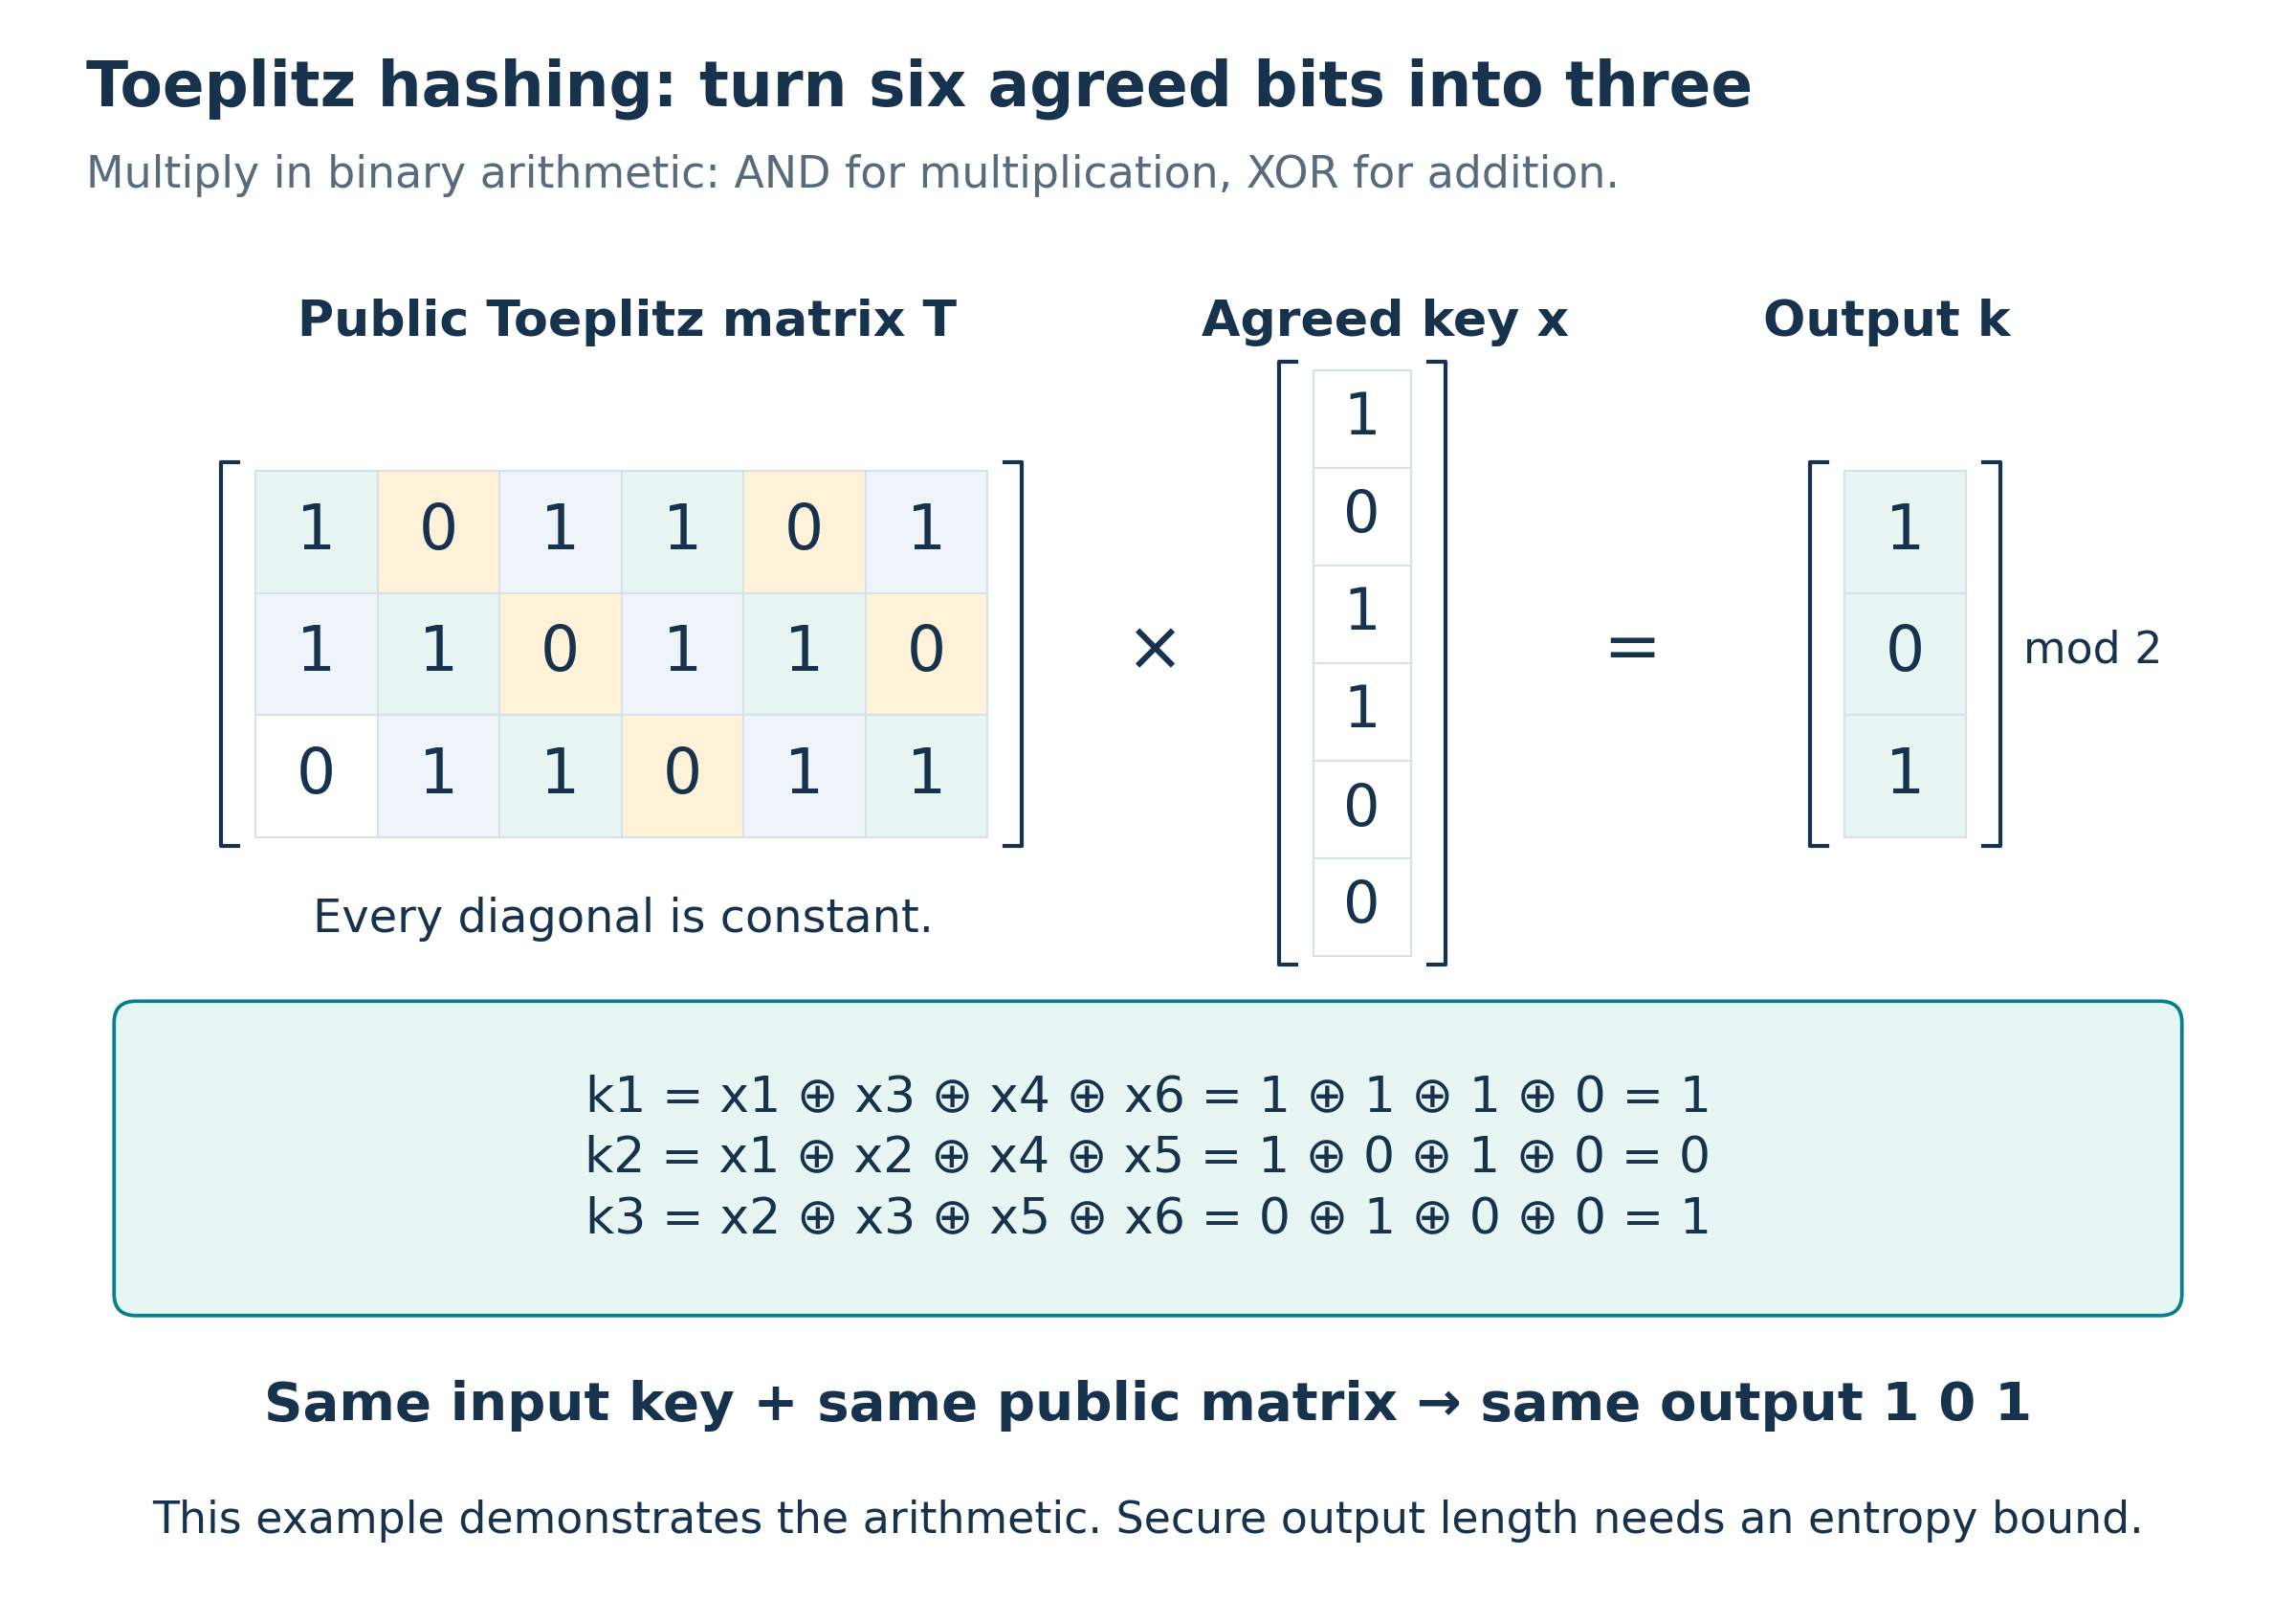

### Step 1 — Calculate this notebook's illustrative output budget

$$\ell_{demo}=\max\left(0,\left\lfloor n[1-h_2(QBER)]-\mathrm{leak}_{EC}-32\right\rfloor\right).$$

Read it in order:

1. Start with the sifted length $n$.
2. Subtract the entropy penalty $nh_2(QBER)$ from the idealized asymptotic single-photon BB84 expression.
3. Subtract the syndrome charge `leak_ec`.
4. Subtract an **illustration reserve of 32 bits**.
5. Round down, then replace negative results with zero.

For the default stored run,

$$\ell_{demo}=\lfloor1197-290.574-598-32\rfloor=276\text{ bits}.$$

The requested length is 256, so the actual output length is $\min(256,276)=256$, provided correction succeeded. The reserve is a teaching choice; it does not establish a security parameter of $2^{-32}$.

### Step 2 — Check whether to stop

The code requires both decoder convergence and equality of Alice's and Bob's corrected arrays. If either fails, it produces no final key. It also stops if the budget is zero. An abort is a meaningful result: the chosen model and settings did not permit continuing.

With full interception, expected QBER is 26% at the default channel noise. Its entropy penalty is large enough to exhaust this roughly half-rate syndrome budget. The decoder may also fail under such errors; the code checks both conditions.

### Step 3 — Build a shared Toeplitz matrix

A Toeplitz matrix has constant values along each diagonal from upper left to lower right. The code creates an $\ell\times n$ binary matrix from its first column and first row, with the top-left value shared. Therefore $\ell+n-1$ independent seed bits specify the matrix.

The seed can be public; the secrecy argument must rely on appropriate uncertainty in the input and a suitable independently chosen hash, rather than secrecy of the matrix. This notebook fixes a pseudorandom seed for reproducibility, so its printed demonstration bits must not be used as a real cryptographic key.

### Step 4 — Multiply and reduce modulo 2

$$k_A=Tx_A^T\pmod2,\qquad k_B=Tx_{B,corrected}^T\pmod2.$$

For a small arithmetic example, use

$$T=\begin{bmatrix}1&0&1&1&0&1\\1&1&0&1&1&0\\0&1&1&0&1&1\end{bmatrix},\qquad x_A=(1,0,1,1,0,0).$$

The three row dot products are 3, 2, and 1. Reducing each modulo 2 gives the three-bit output **101**. The same calculation on corrected Bob's **101100** also gives **101**. This six-to-three-bit example illustrates matrix arithmetic only; it is not a security claim about that tiny input.

Identical inputs and the same matrix give identical outputs. The default run prints a 256-bit result and `Final keys identical: True`; the first 64 displayed bits are only a preview. Matching outputs show this simulated calculation agrees, not that secrecy has been proved.

### What this budget does and does not establish

The formula uses full-key observed QBER, an asymptotic entropy expression, and a fixed reserve. It is not a finite-key or composable security guarantee. A complete protocol would need justified parameter-estimation bounds, authentication and verification accounting, a security parameter, and an appropriate bound on Eve's remaining information. Her “40 known bits” earlier cannot simply replace those bounds because public reconciliation can reveal further information. Privacy amplification is the relevant mechanism; choosing a secure output length requires the analysis omitted by this teaching model.

In [16]:
def toeplitz_matrix(first_col, first_row):
    first_col = np.asarray(first_col, dtype=np.uint8)
    first_row = np.asarray(first_row, dtype=np.uint8)
    assert first_col[0] == first_row[0]
    m, n = len(first_col), len(first_row)
    T = np.empty((m, n), dtype=np.uint8)
    for i in range(m):
        for j in range(n):
            if j >= i:
                T[i, j] = first_row[j-i]
            else:
                T[i, j] = first_col[i-j]
    return T

REQUESTED_FINAL_BITS = 256
DEMO_RESERVE_BITS = 32
demo_key_budget = max(0, int(np.floor(
    N_KEY * (1.0 - float(h2(observed_qber))) - leak_ec - DEMO_RESERVE_BITS
)))
reconciliation_ok = converged and np.array_equal(alice_key, bob_corrected)
FINAL_BITS = min(REQUESTED_FINAL_BITS, demo_key_budget) if reconciliation_ok else 0
alice_final = np.empty(0, dtype=np.uint8)
bob_final = np.empty(0, dtype=np.uint8)
final_key_match = False

print("Illustrative entropy budget:", demo_key_budget, "bits")
if FINAL_BITS == 0:
    abort_reason = "reconciliation failed" if not reconciliation_ok else "no positive entropy budget"
    print("ABORT: no final key produced (" + abort_reason + ").")
else:
    hash_rng = np.random.default_rng(2026)
    first_col = hash_rng.integers(0, 2, size=FINAL_BITS, dtype=np.uint8)
    first_row = hash_rng.integers(0, 2, size=N_KEY, dtype=np.uint8)
    first_row[0] = first_col[0]
    T = toeplitz_matrix(first_col, first_row)

    alice_final = (T @ alice_key) % 2
    bob_final = (T @ bob_corrected) % 2
    final_key_match = bool(np.array_equal(alice_final, bob_final))

    print("Final key length:", len(alice_final), "bits")
    print("Final keys identical:", final_key_match)
    print("Alice final key (first 64 bits):")
    print(''.join(map(str, alice_final[:64].tolist())))


Illustrative entropy budget: 276 bits
Final key length: 256 bits
Final keys identical: True
Alice final key (first 64 bits):
1000111010011111010010010011111010000101011010001110110011000011


## 14. Read the end-to-end summary without mixing the two experiments

The next cell gathers important results in one place. Read its two groups separately.

**First group: Part I FSO baseline.** At the fixed summary distance of 20 km, expect efficiency about 0.001376, detection gain about 0.0006898, and BB84 QBER about 1.641%. The three rates use their respective formulas and remain baseline predictions without Eve.

**Second group: Part II sampled bit experiment.** With the default 8% Eve interception and 2% independent channel error setting, the stored seeded run has 1,197 sifted bits, 48 initial disagreements, 40 Alice bits directly known to Eve before syndrome exchange, and about 4.010% QBER. The decoder takes 5 iterations, corrects all simulated disagreements, and permits the requested 256-bit illustrative hash output.

To explain the result in your own words, follow these steps:

1. State the link assumptions and the selected example distance.
2. State the separate attack and channel-error settings used for the bit simulation.
3. Explain how sifting changed the bit count.
4. Compare QBER before and after reconciliation.
5. State the syndrome leakage and whether the final-budget check passed.
6. Describe the final key as an educational simulation result, with the security limitations from Section 13.

After changing parameters, use the newly executed values rather than copying these baseline numbers. An unsuccessful run can still be informative if you explain whether decoding, the entropy budget, or both caused the stop.

In [17]:
summary_distance = 20.0
Q20, E20, eta20 = gain_and_qber(summary_distance, "BB84")

print("="*64)
print("QKD OVER FSO - PROJECT SUMMARY")
print("="*64)
print(f"Example FSO distance                  : {summary_distance:.1f} km")
print(f"Total deterministic path efficiency  : {eta20:.4e}")
print(f"Detection gain Q_mu                   : {Q20:.4e}")
print(f"Modelled BB84 QBER                    : {100*E20:.3f} %")
print(f"BB84 simplified rate / pulse          : {bb84_reference_rate(summary_distance):.4e}")
print(f"Decoy-BB84 rate / pulse               : {decoy_bb84_rate(summary_distance):.4e}")
print(f"Legacy DPS teaching proxy / pulse            : {dps_teaching_proxy(summary_distance):.4e}")
print("-")
print(f"Eve intercept fraction                : {100*EVE_INTERCEPT_FRACTION:.1f} %")
print(f"QBER without Eve (same noise)          : {100*no_eve_qber:.3f} %")
print(f"Eve known bits before syndrome        : {eve_known_bits} / {N_KEY}")
print(f"LDPC demo key length                  : {N_KEY} bits")
print(f"LDPC QBER before                      : {100*observed_qber:.3f} %")
print(f"LDPC QBER after                       : {100*qber_after:.3f} %")
print(f"LDPC converged / iterations           : {converged} / {iterations}")
print(f"Toeplitz final key length             : {FINAL_BITS} bits")
print(f"Alice/Bob final key match             : {final_key_match if FINAL_BITS else 'no key produced'}")
print("="*64)

QKD OVER FSO - PROJECT SUMMARY
Example FSO distance                  : 20.0 km
Total deterministic path efficiency  : 1.3761e-03
Detection gain Q_mu                   : 6.8983e-04
Modelled BB84 QBER                    : 1.641 %
BB84 simplified rate / pulse          : 2.5495e-04
Decoy-BB84 rate / pulse               : 1.3629e-04
Legacy DPS teaching proxy / pulse            : 5.5562e-04
-
Eve intercept fraction                : 8.0 %
QBER without Eve (same noise)          : 2.339 %
Eve known bits before syndrome        : 40 / 1197
LDPC demo key length                  : 1197 bits
LDPC QBER before                      : 4.010 %
LDPC QBER after                       : 0.000 %
LDPC converged / iterations           : True / 5
Toeplitz final key length             : 256 bits
Alice/Bob final key match             : True


## 15. Try simple experiments, one change at a time

Use a small experiment table with columns for the setting, your prediction, measured result, and explanation. Keep the first default run as your reference. Restart and run all after each parameter change so captured defaults and dependent arrays update together.

### Experiment A — Improve the receiver

1. Record the 20 km baseline efficiency and decoy rate.
2. Change `receiver_radius_m` from 0.10 to 0.15.
3. Predict that collecting more of the beam will improve efficiency.
4. Rerun and compare the same table row and rate graph.
5. Restore 0.10 before the next experiment.

### Experiment B — Add background counts

1. Record the long-distance QBER curve with `dark_yield = 2e-6`.
2. Increase it to `1e-5`.
3. Check where QBER rises and the modelled rates approach zero.
4. Explain why background matters more when signal detections are rare.

This changes Part I; Part II still uses its independently specified channel-error probability.

### Experiment C — Watch Eve's effect

1. Use `eve_intercept_fraction = 0.0` and keep the channel probability at 0.02.
2. Rerun, then repeat with 0.08 and 1.0.
3. Compare expected QBER, observed QBER, and Eve's known-bit count.
4. Record whether the decoder succeeds and whether a final key is produced.

The expected QBERs are 2%, 3.92%, and 26%, respectively. Sampled values will differ. An Eve setting of zero removes this attack's disturbance; it does not remove channel noise.

### Experiment D — Test the correction stage

1. Set Eve interception to zero to simplify interpretation.
2. Try `demo_channel_qber` values 0.01, 0.04, and 0.08.
3. Record errors before correction, iterations, convergence, and exact corrected-key equality.
4. Check the final budget separately from decoder success.

One seed gives one example outcome, not a reliable performance curve. Studying success probability would require multiple seeds and reporting the number of trials. Increasing errors need not make every individual sampled decoder run behave monotonically.

### Experiment E — Make fading stronger

Try `turbulence_strength` values 0.10, 0.25, and 0.50. Compare the histogram width, mean QBER, and 95th percentile. Explain the distinction between fluctuations in the link model and Eve's separate attack model.

For a presentation, select two or three experiments you can explain clearly. Keep the DPS curve labelled as a proxy, call the LDPC graph a teaching construction, and describe the final-key budget as illustrative. These labels are part of correctly interpreting the results.

## 16. References and where the explanations come from

The expanded walkthrough explains the equations and operations present in this notebook. Its numerical examples refer to the supplied settings and saved seeded outputs; rerunning after parameter changes can give different values.

The original project lists these background references:

- N. K. Kundu, course lecture material on realistic QKD, BB84, decoy-state QKD, DPS/COW, entanglement-based QKD, classical post-processing, LDPC reconciliation, and privacy amplification.
- Y. Luo, X. Cheng, H.-K. Mao, and Q. Li, *An Overview of Postprocessing in Quantum Key Distribution*, Mathematics 12 (2024), 2243.
- G. Limei, R. Qi, J. Di, and H. Duan, *QKD Iterative Information Reconciliation Based on LDPC Codes*, International Journal of Theoretical Physics 59 (2020), 1717–1729.
- [IBM Quantum Learning: Quantum Key Distribution](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/quantum-key-distribution), for background on BB84 basis measurements and intercept-resend disturbance.

**Source status:** the cited course PDFs were not present in the workspace during this revision. Their content and the inherited bibliography have not been independently confirmed against those PDFs. Existing code comments and plot labels that refer to lecture material are preserved from the original executable notebook, rather than a new claim of source verification.

The FSO propagation equations are project-level engineering assumptions. The new diagrams are explanatory illustrations of this notebook's workflow and small worked examples, rather than copied lecture figures. The small parity and hash examples teach the arithmetic; the executable simulation uses its own larger generated arrays.

For primary-source reading beyond the simplified implementation, see [Ma et al., Practical Decoy State for Quantum Key Distribution](https://arxiv.org/abs/quant-ph/0503005) on decoy-state estimation, [Marøy et al., Error Estimation, Error Correction and Verification In Quantum Key Distribution](https://arxiv.org/abs/1210.6520) on correction and verification, and [Tomamichel et al., Leftover Hashing Against Quantum Side Information](https://arxiv.org/abs/1002.2436) on privacy amplification. These works provide background; citing them does not make the notebook's simplified budget a proved security result.

## 17. DPS protocol statistics and atmospheric fading

This extension uses `shared/physics.py`, `shared/scenarios.py` and `shared/reporting.py`.
Earlier sections retain their historical deterministic models and finite BB84 demonstrations.
**DPS uses relative phases between coherent pulses, a one-pulse delay interferometer,
two threshold detectors and explicit valid-slot accounting.** It is not the earlier DPS teaching curve.

**DPS protocol QBER** is a detection statistic. **DPS illustrative rate proxy** uses a
collision-inspired privacy term from the restricted individual-attack analysis, combined
with the detector model described in `DPS_THEORY.md`. A DPS-specific composable secret-key
security bound has not been implemented or established. Its integral is an integrated
proxy, not certified secret-key material. The old BB84/Eve/LDPC/Toeplitz example is not DPS.

Fading is a normalized collected-power multiplier: `exp(sigma*X - sigma**2/2)`;
`sigma**2` is log-irradiance variance. Temporal correlation is phenomenological,
with `rho=exp(-dt/tau_c)` and stationary initialization. The detector factor is fixed;
optical clipping is reported. Ground links have independent random streams; vacuum
inter-satellite links do not receive atmospheric fading. No measured data are used.

Change the protocol and mode below, then restart and run all. Defaults here explicitly
select correlated fading for comparison; library defaults remain `none`.
Stage 3 retains trusted BB84/DPS and separate BBM92 operation. BBM92 always requires
simultaneous visibility and recalculates singles and accidental coincidences on both arms.
Hardware, source, clock resources and security assumptions differ across protocols.


Active protocol: DPS QKD
DPS parameters: {
  "mean_photons": 0.1,
  "visibility": 0.98,
  "phase_error_rad": 0.0,
  "background_per_detector": 1e-06,
  "ec_efficiency": 1.16,
  "pulse_rate_hz": 100000000.0,
  "duty": 0.8,
  "train_pulses": 1024,
  "guard_slots": 1
}
Fading parameters: {
  "mode": "correlated_lognormal",
  "sigma": 0.3,
  "correlation_time_s": 2.0,
  "seed": 123
}
DPS illustrative rate proxy; no composable security bound established


| Quantity (units in field name) | Value |
|---|---|
| mean_qber | 0.017445129743837315 |
| median_qber | 0.0171500617696305 |
| p95_qber | 0.021241717824371863 |
| mean_rate_bps | 5074.30891831093 |
| median_rate_bps | 4919.989142762337 |
| p05_rate_bps | 2656.8561917485517 |
| outage_fraction | 0.0 |
| pooled_qber | 0.01698294119944454 |
| integrated_rate_bits | 507352.5774092879 |
| time_outage_fraction | 0.0 |
| rate_at_mean_efficiency_bps | 5069.604928288331 |
| rate_at_mean_efficiency_scope | single continuously open gate at mean eta; includes unavailable samples in mean eta |

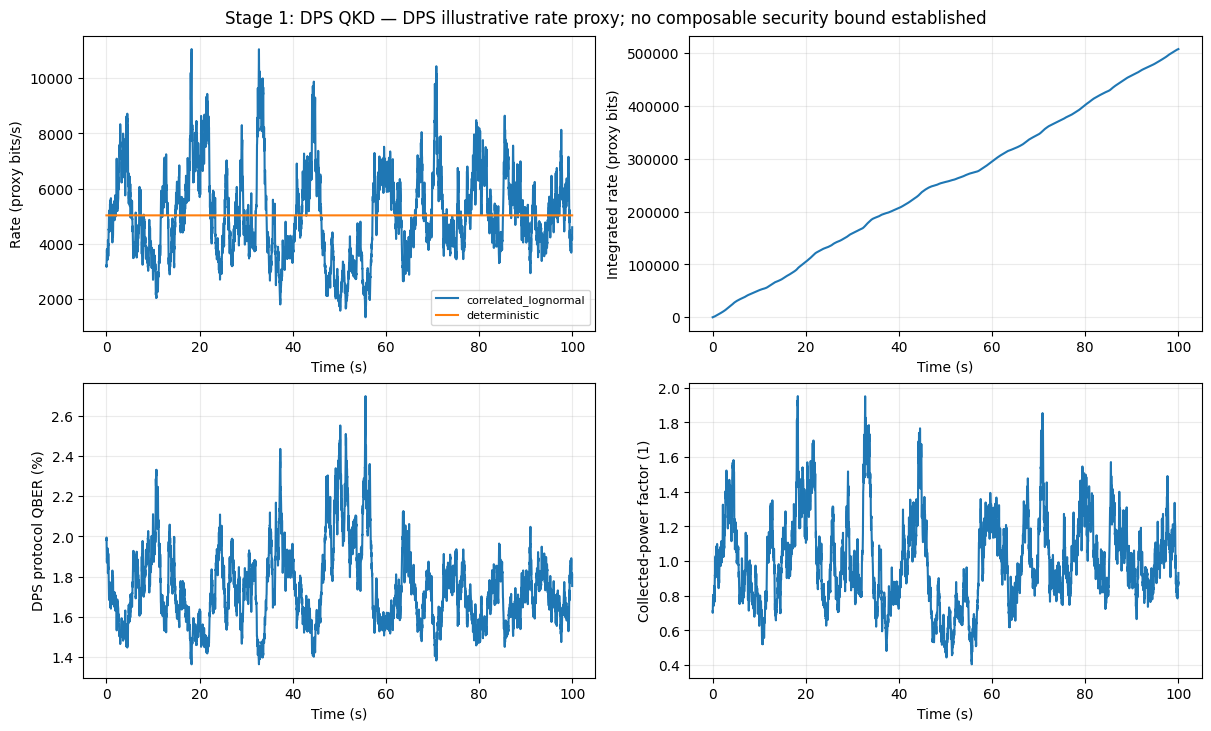

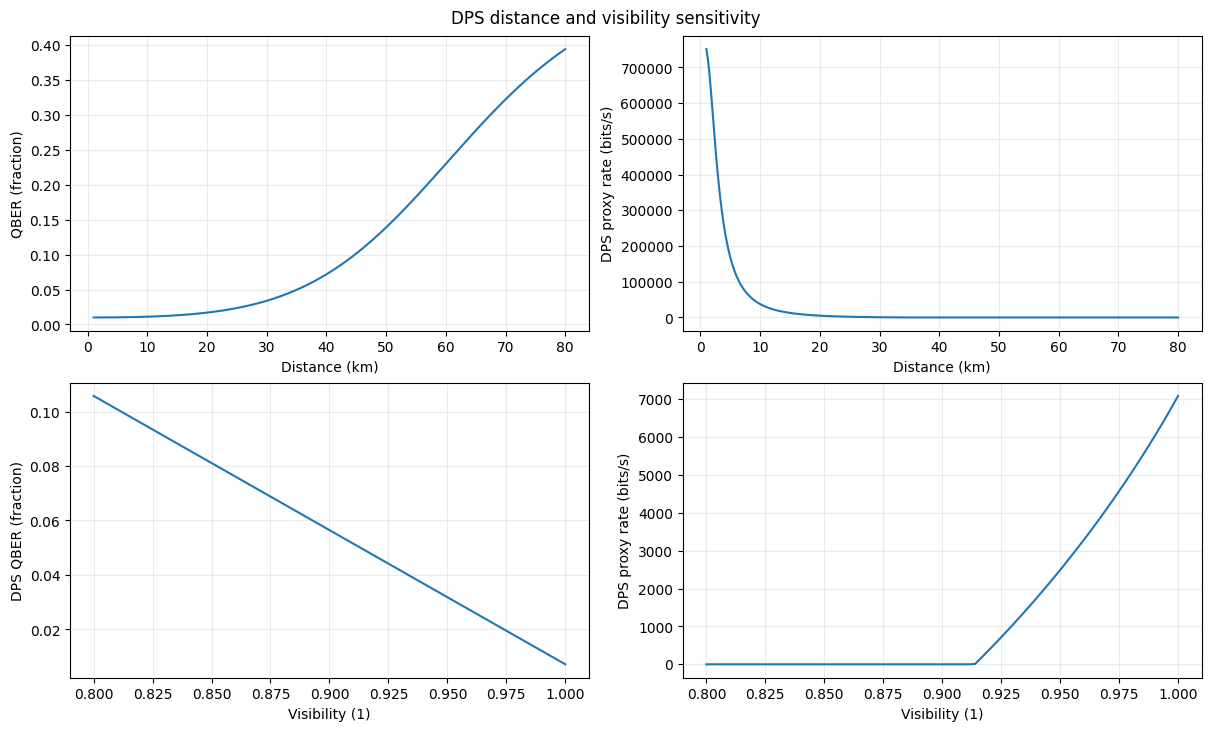

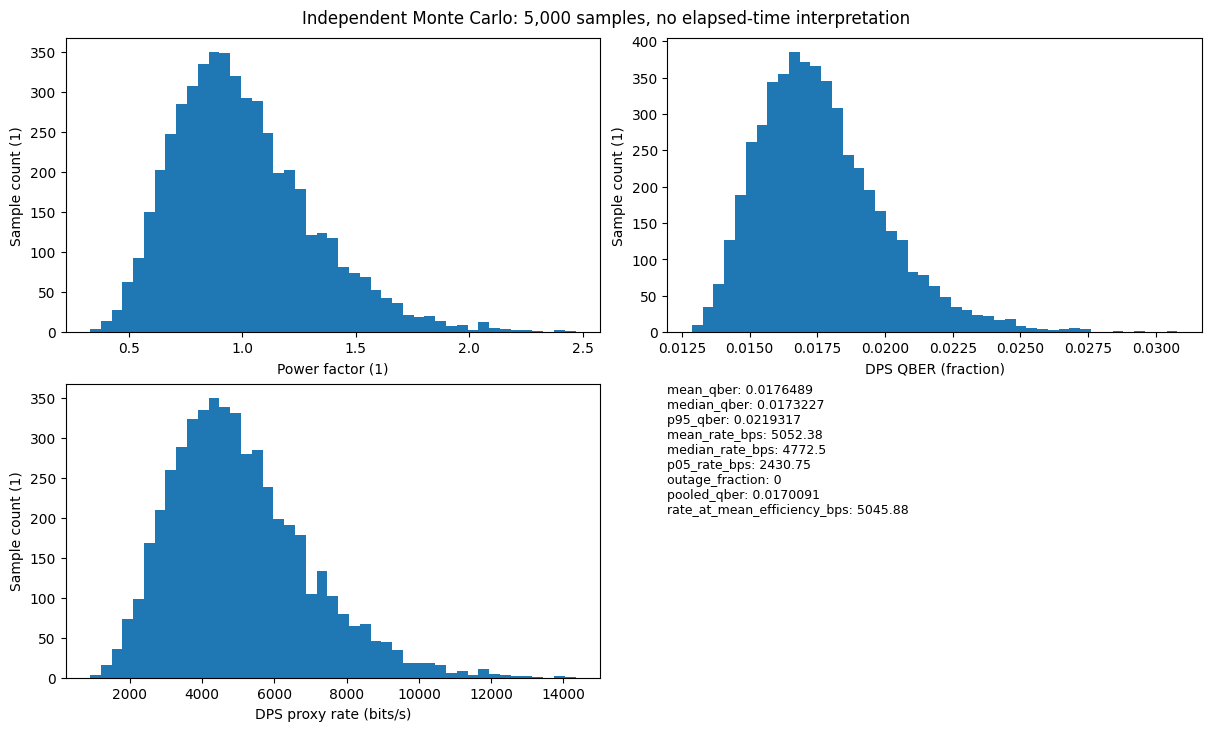

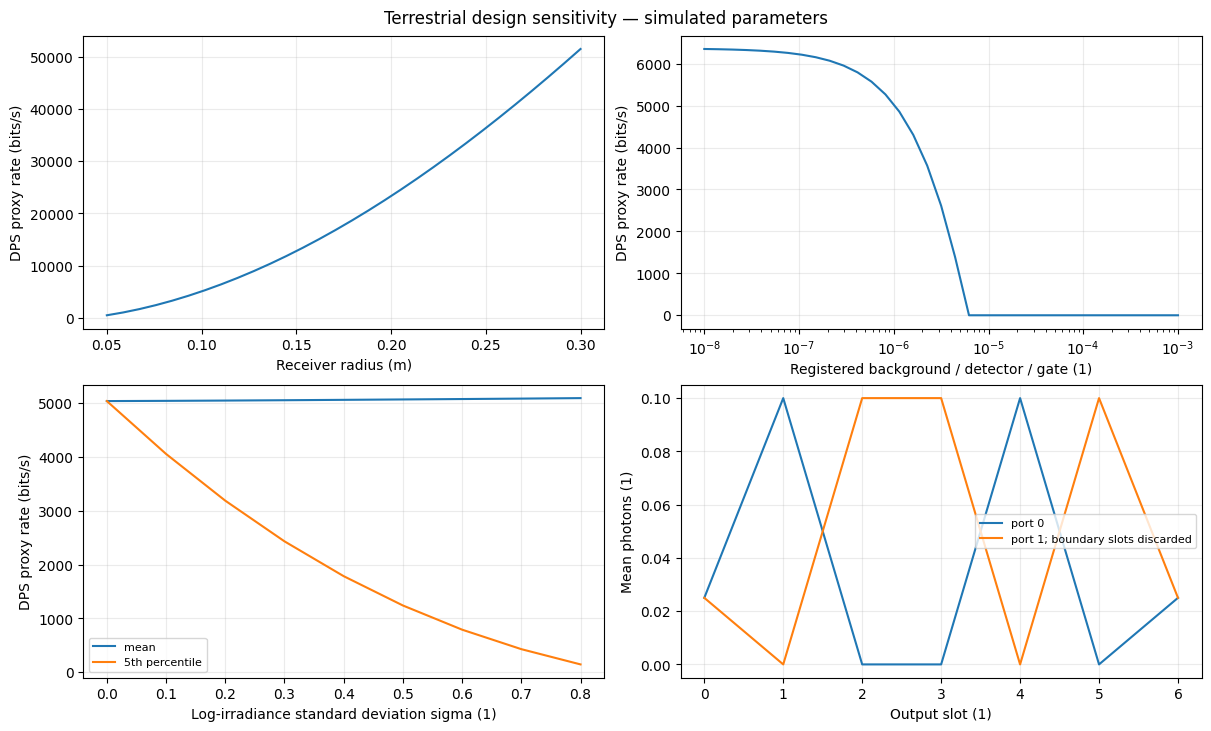

Exports: d:\IIT Class\Project\Submission\1-Basic LOS FSO\dps_turbulence_notebook_results


In [18]:
from pathlib import Path
import sys, json
from dataclasses import asdict
from IPython.display import display, Markdown, Image
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "shared" / "physics.py").is_file())
if str(project_root) not in sys.path: sys.path.insert(0, str(project_root))
from shared.physics import DPSParameters, FadingParameters
from shared.scenarios import run_stage
from shared.reporting import export_result, plot_result, study
import matplotlib.pyplot as plt

active_protocol = "DPS QKD"  # Stage 1: BB84, Decoy-state BB84, DPS QKD; others: latter two
architecture = "trusted"    # Stage 3 only: trusted or bbm92
dps_settings = DPSParameters()
fading_settings = FadingParameters(mode="correlated_lognormal", sigma=0.3, correlation_time_s=2.0, seed=123)
extra = {"mode": architecture} if 1 == 3 else {}
extension_result = run_stage(1, protocol=active_protocol, fading=fading_settings, dps=dps_settings, **extra)
extension_baseline = run_stage(1, protocol=active_protocol, dps=dps_settings, **extra)
print("Active protocol:", extension_result["metadata"]["protocol"])
print("DPS parameters:", json.dumps(asdict(dps_settings), indent=2))
print("Fading parameters:", json.dumps(asdict(fading_settings), indent=2))
print(extension_result["metadata"]["security_status"])
summary_rows = "\n".join(f"| {k} | {v} |" for k,v in extension_result["summary"].items())
display(Markdown("| Quantity (units in field name) | Value |\n|---|---|\n" + summary_rows))
extension_figures = plot_result(extension_result, extension_baseline)
plt.show()
for extension_figure in extension_figures: plt.close(extension_figure)
extension_folder = project_root / '1-Basic LOS FSO' / "dps_turbulence_notebook_results"
export_result(extension_result, extension_folder)
print("Exports:", extension_folder)


### Interpretation, ensemble study and exports

Mean instantaneous QBER excludes undefined zero-detection samples. Pooled QBER is total
expected errors divided by total expected detections. They generally differ. Sample outage
and time-weighted outage are both exported. Mean instantaneous rate and the rate at mean
efficiency also differ; the latter is a hypothetical continuously open link, not a pass average.
For unavailable satellite contacts, the detection gates are closed and rates are zero.

The following reproducible **default DPS design study** is separate from the selected run above.
It uses fixed geometry and 12 independent seeds, plus five seeds at each turbulence strength.
The plotted sample intervals are descriptive, not confidence bounds or proof of a general trend.
Monte Carlo histograms have sample-count axes, not seconds. All zero rates remain zero.
Reports contain parameters, assumptions, units, seeds, CSV arrays and JSON metadata.


| Seed | Integrated DPS proxy (bits) | Outage sample fraction |
|---|---|---|
| 1000 | 477604 | 0.0000 |
| 1001 | 545878 | 0.0000 |
| 1002 | 454981 | 0.0000 |
| 1003 | 412575 | 0.0000 |
| 1004 | 501806 | 0.0000 |
| 1005 | 543111 | 0.0000 |
| 1006 | 498613 | 0.0000 |
| 1007 | 503889 | 0.0000 |
| 1008 | 516194 | 0.0000 |
| 1009 | 536647 | 0.0000 |
| 1010 | 521932 | 0.0000 |
| 1011 | 515097 | 0.0000 |

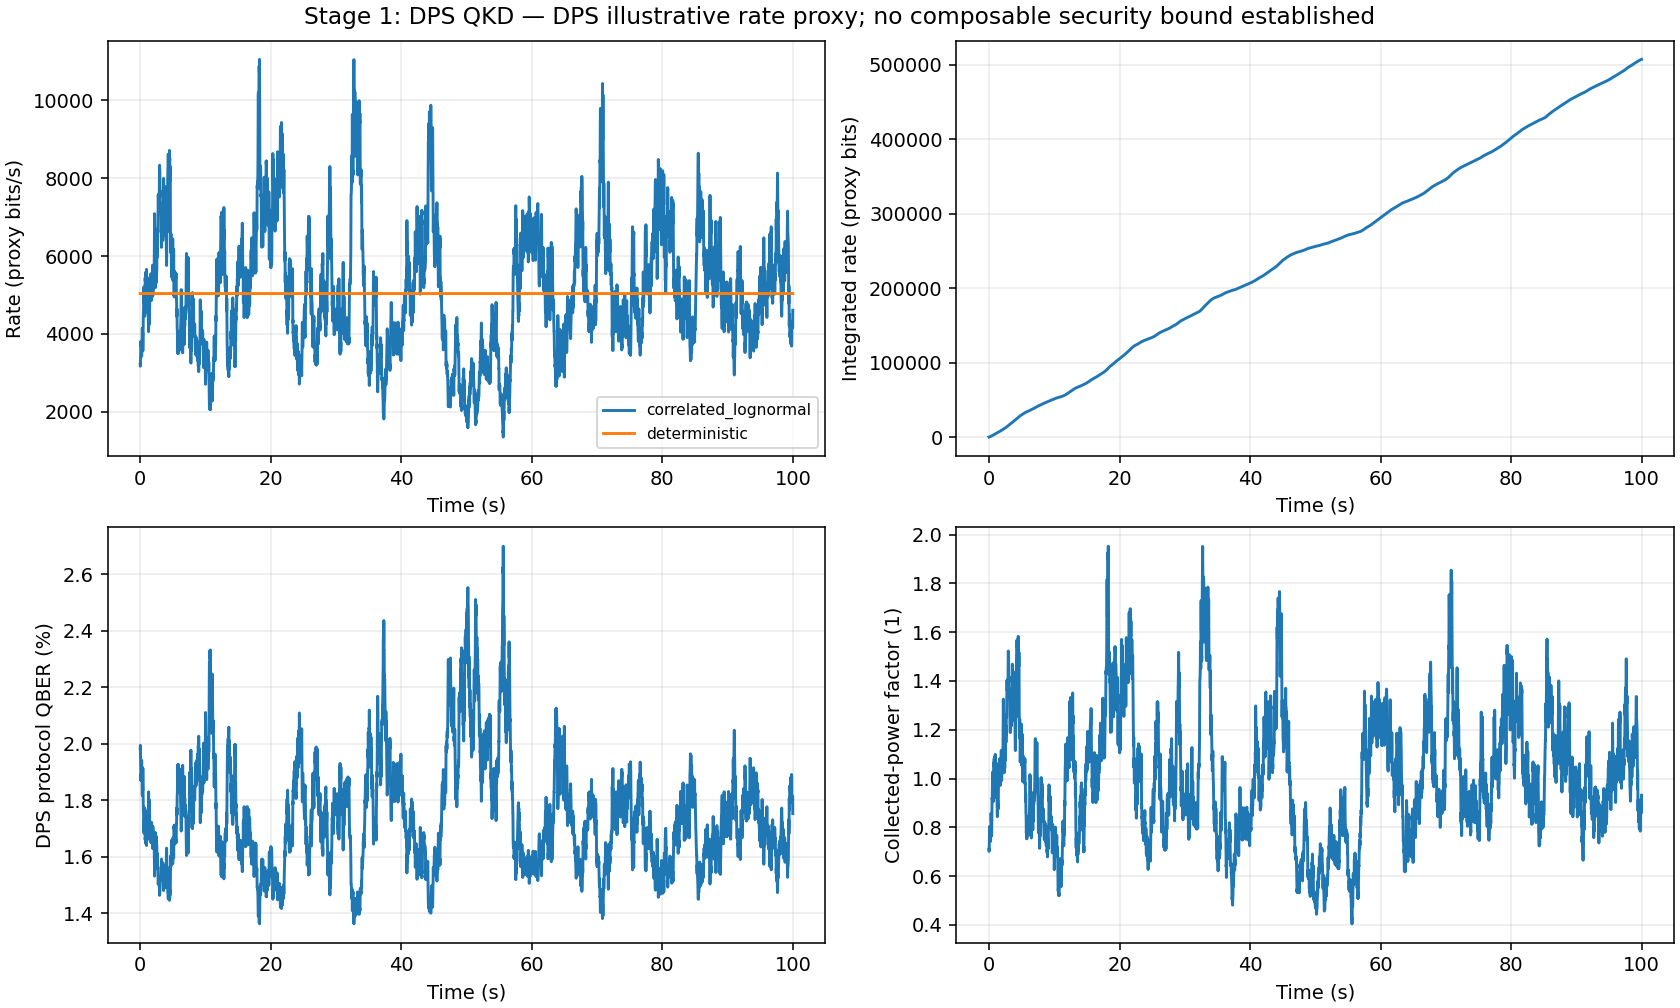

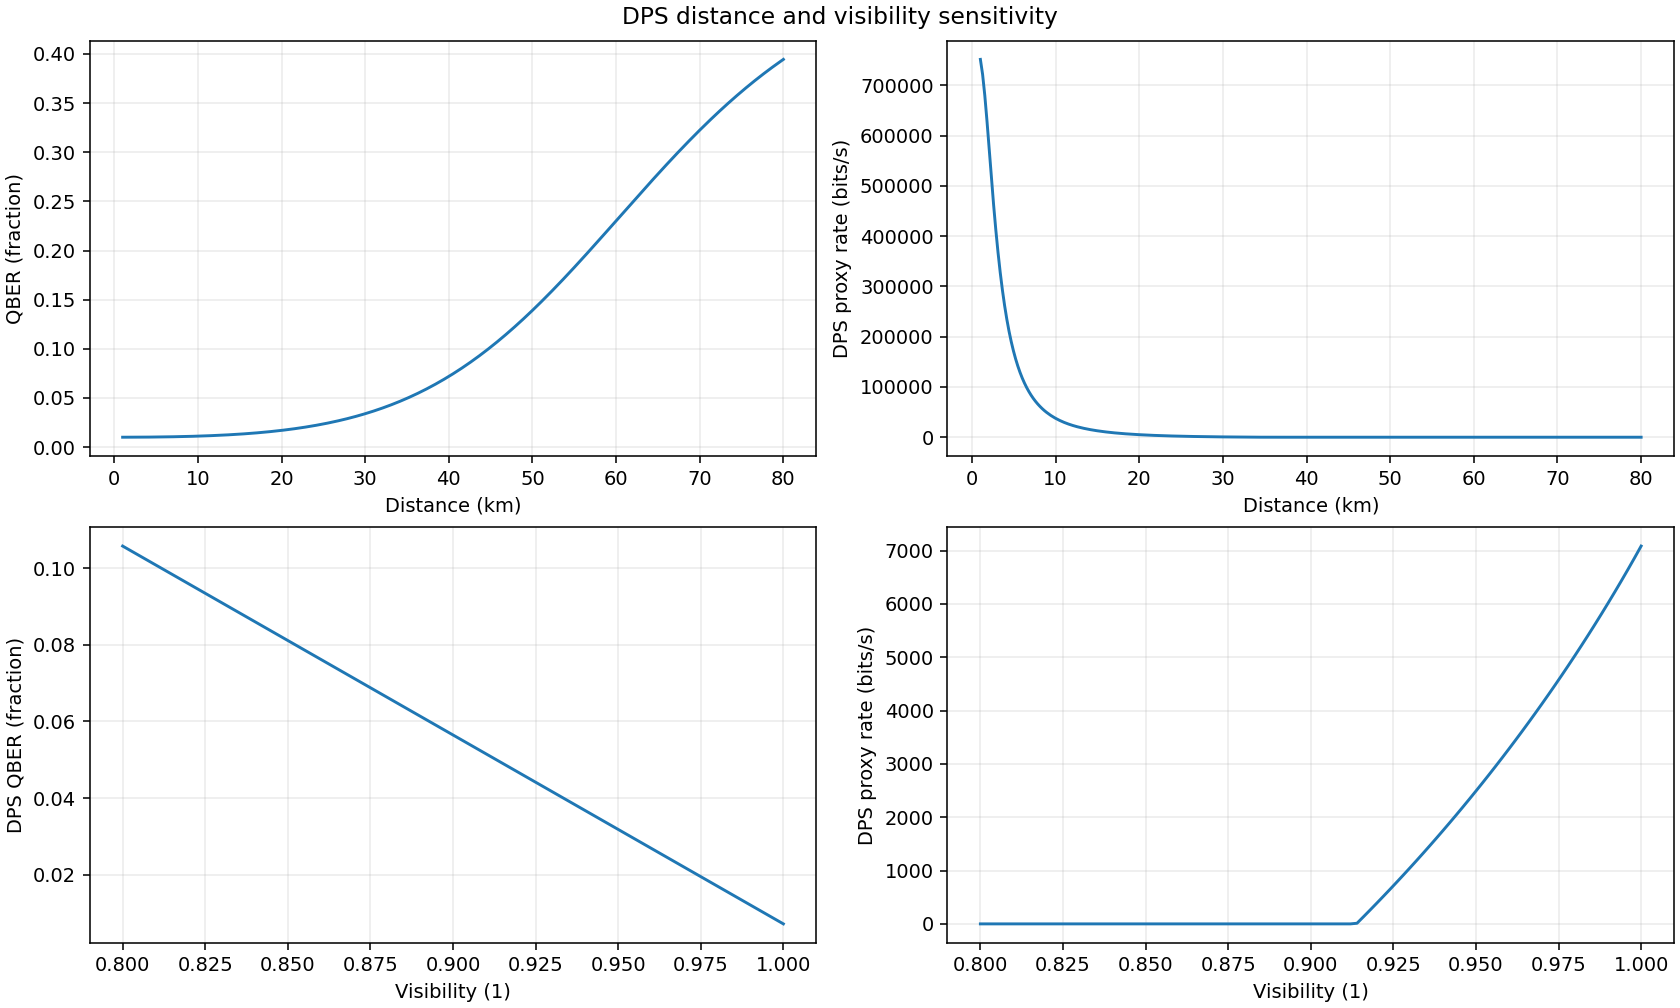

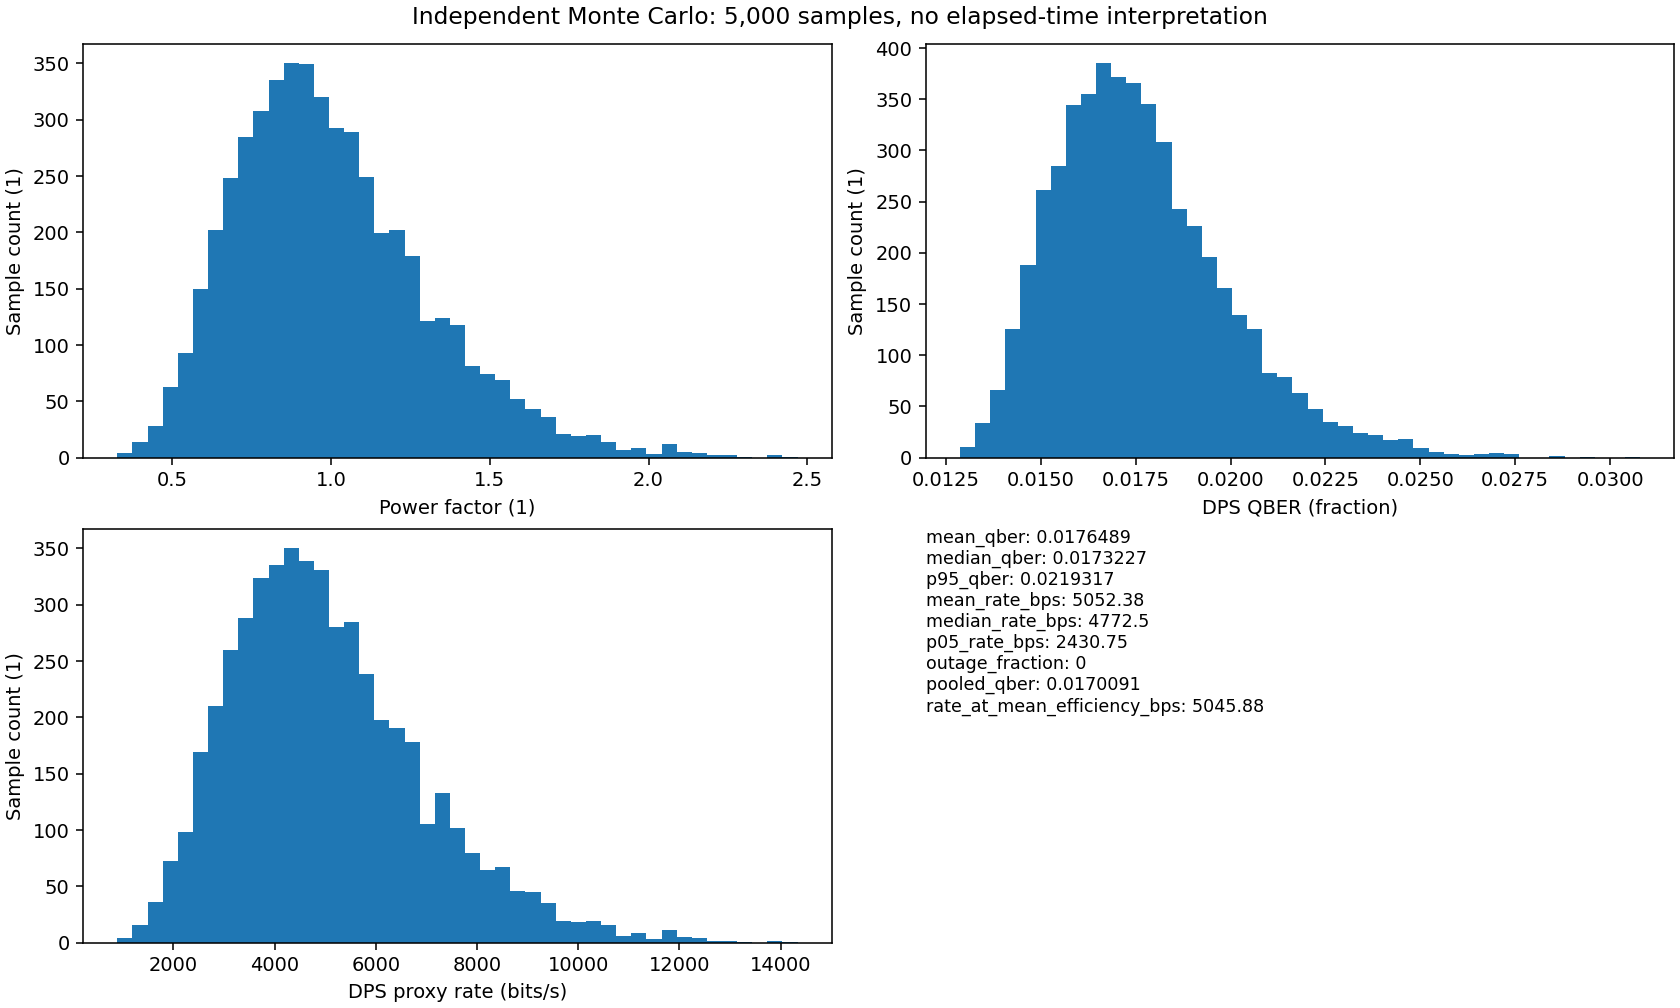

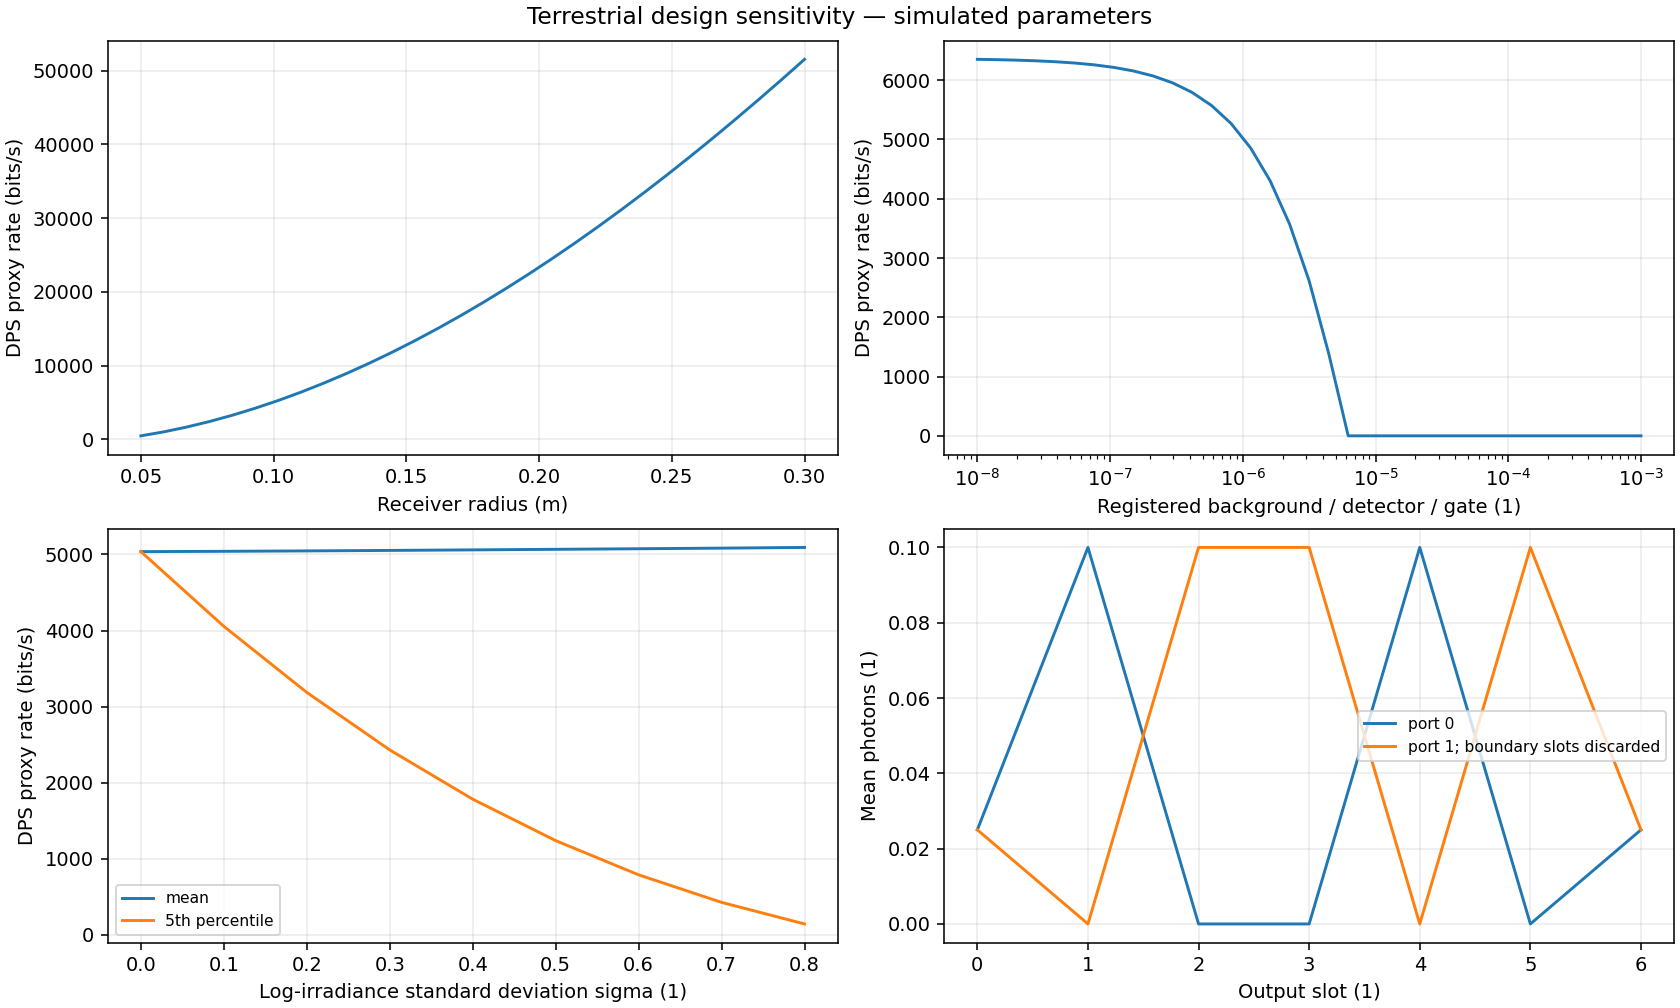

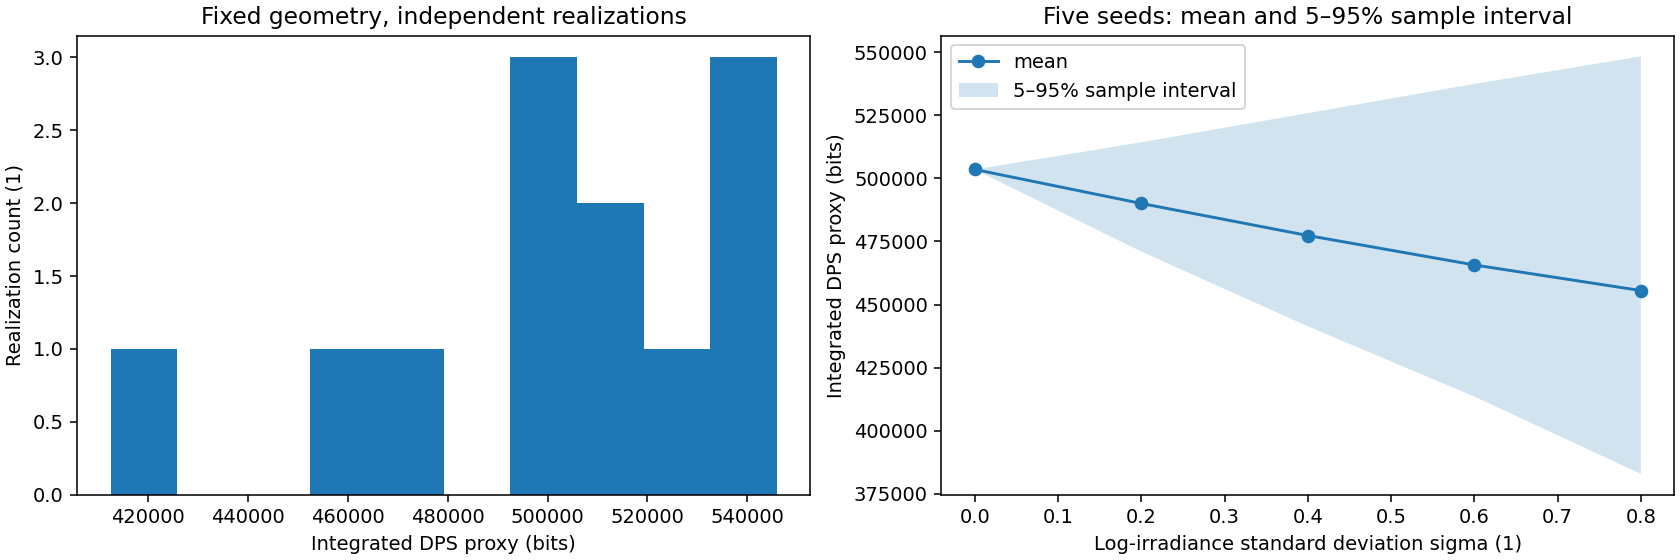

Default study HTML: d:\IIT Class\Project\Submission\1-Basic LOS FSO\dps_turbulence_results\report.html


In [19]:
default_study_folder = project_root / '1-Basic LOS FSO' / "dps_turbulence_results"
default_study_result, realization_rows, sensitivity_rows = study(1, default_study_folder)
display(Markdown("| Seed | Integrated DPS proxy (bits) | Outage sample fraction |\n|---|---|---|\n" +
    "\n".join(f"| {row['seed']} | {row['integrated_rate_bits']:.6g} | {row['outage_fraction']:.4f} |" for row in realization_rows)))
for image_path in sorted(default_study_folder.glob("figure_*.png")):
    display(Image(filename=str(image_path)))
print("Default study HTML:", default_study_folder / "report.html")
